# Data Mining
# Week 10
# Submitter - Himanshu Singh
# Fraud Waste Abuse Detection in Healthcare Insurance - Project Milestone 3
# Model Building and Evaluation


# Milestone 1 **************************************************************************************** 

## Problem Statement

The primary objective of this project is to develop a predictive model to identify Fraud, Waste, and Abuse (FWA) among healthcare providers. By analyzing claims data, the project aims to "Predict potentially fraudulent providers" while uncovering the most significant variables that signal suspicious behavior. This intelligence allows organizations to flag high-risk claims for in-depth investigation, ensuring that resources are directed toward the most likely instances of financial leakage.

## Problem Description
Healthcare insurance is a vital pillar of social stability, protecting citizens from the financial hardships of medical uncertainty. However, the integrity of both public and private insurance schemes is constantly threatened by Fraud, Waste, and Abuse (FWA):

Fraud: Intentional deception or misrepresentation, such as billing for services never rendered or "phantom" patients.
Waste: Overutilization of services or practices that result in unnecessary costs, such as performing excessive diagnostic tests that are not medically required.
Abuse: Actions that are inconsistent with sound fiscal, business, or medical practices, resulting in improper payment (e.g., upcoding or unbundling procedures).

FWA is often an organized crime involving collusion between providers, physicians, and beneficiaries. Specifically, Provider Fraud is a massive burden on Medicare; for instance, providers may exaggerate billing amounts or facilitate benefits for unauthorized individuals.

The cost of misidentification is high: failing to detect FWA leads to substantial financial losses, while incorrectly flagging legitimate providers (False Positives) causes administrative friction and delays essential patient care. A precise, data-driven approach is required to balance aggressive cost recovery with the smooth adjudication of valid claims.

### Real-Life Examples in FWA Detection
Fraud (Intentional Deception): A provider submits claims for a series of complex MRIs for patients who, according to demographic data, live 500 miles away and never visited the clinic.
Data Mining Perspective: We can look for geospatial anomalies and a lack of corresponding primary care referrals.

Waste (Unnecessary Costs): A clinic consistently orders expensive "comprehensive metabolic panels" for every single patient visit, regardless of the diagnosis (e.g., even for a simple flu shot).
Data Mining Perspective: This is identified through frequency analysis and comparing a provider's behavior against the "peer group" average for the same specialty.

Abuse (Improper Practice): A surgeon performs a single operation but bills for three separate "sub-procedures" to increase the payout (known as unbundling).
Data Mining Perspective: We can use Association Rule Mining to find procedure codes that should logically be billed under a single global fee but are appearing as separate line items.

Source of data: Elsevier''s Mendeley Data repository is a participating member of the National Institutes of Health (NIH) Office of Data Science Strategy (ODSS) GREI project.
liang, tim (2024), “HEALTHCARE PROVIDER FRAUD DETECTION ANALYSIS”, Mendeley Data, V1, doi: 10.17632/gsn2hyty37.1
https://data.mendeley.com/datasets/gsn2hyty37/1

In [611]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC  
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import roc_curve, auc , f1_score
from sklearn.metrics import confusion_matrix

In [612]:
data = pd.read_csv('Train.csv')
data_beneficiary = pd.read_csv('Train_Beneficiarydata.csv')
data_inpatient = pd.read_csv('Train_Inpatientdata.csv')
data_outpatient = pd.read_csv('Train_Outpatientdata.csv')

# Exploratory Data Analysis

# 1 . Procedure Code and Diagnosis Codes Analysis

## Inpatient Records Data Analysis

### Inpatient Data - Inpatient Data refers to records for patients who have been formally admitted to a hospital or medical facility for at least one night.


We will try to analyze the data we have

This data contains Diagnosis Code and Procedure Codes

* Diagnosis Codes (primarily ICD-10 codes) are the standardized alphanumeric strings used to describe a patient’s medical condition, symptoms, or injuries.
* Procedure Codes are standardized numeric or alphanumeric codes used to identify the specific medical, surgical, or diagnostic services provided to a patient. While Diagnosis Codes explain "why" the patient is there, Procedure Codes explain "what" was done to them.

Since there are multiple service and procedure code associated to each claim we will combine them together and sort, so that it doesn't give us multiple sets of same procedure and services

Eg : Knee Surgery will have Anaesthesia + Arthroscopically aided ACL reconstruction, the sort and combine will give us combination of procedure.

We will try to find which Procedure and Diagnonsis are the top reported in the dataset we got.

In [613]:
def get_year(date):
    """This function returns year from date"""
    date = str(date)
    return(int(date[:4]))

def get_month(date):
    """This function returns month from date"""
    date = str(date)
    return (int(date[5:7]))
# Function to analyse categorical columns

def analyse_cat_columns(dataset, col_to_analyse, prefix='', title='Distribution in percentage', 
                        top_val=30, y_lim=None, color='green'):
    """Plots a bar graph for the percentage distribution of a categorical column."""
    
    # Calculate counts and convert to percentage in one step
    counts = dataset[col_to_analyse].value_counts().head(top_val)
    percentages = (counts / len(dataset)) * 100
    
    # Create the plot labels with the optional prefix
    labels = [f"{prefix}{label}" for label in percentages.index]
    
    # Plotting
    plt.figure(figsize=(10, 3))
    plt.bar(labels, percentages.values, color=color)
    
    # Formatting
    plt.title(title)
    plt.ylabel('Percentage (%)')
    plt.xlabel(col_to_analyse)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    if y_lim is not None:
        plt.yticks(y_lim)
        
    plt.tight_layout()
    plt.show()

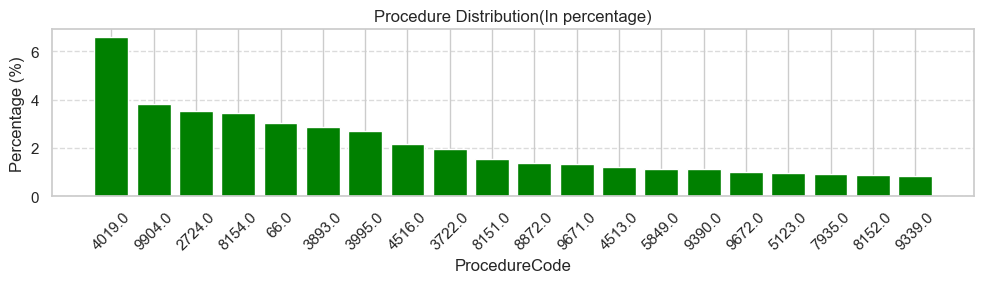

In [614]:
# Select all columns that start with 'ClmProcedureCode'
proc_cols = [col for col in data_inpatient.columns if 'ClmProcedureCode' in col]

# Concatenate them all and drop NaNs
inpatient_df = pd.DataFrame(
    pd.concat([data_inpatient[col] for col in proc_cols], axis=0).dropna(),
    columns=['ProcedureCode']
)
analyse_cat_columns(inpatient_df,col_to_analyse='ProcedureCode' ,title = 'Procedure Distribution(In percentage)',top_val = 20)

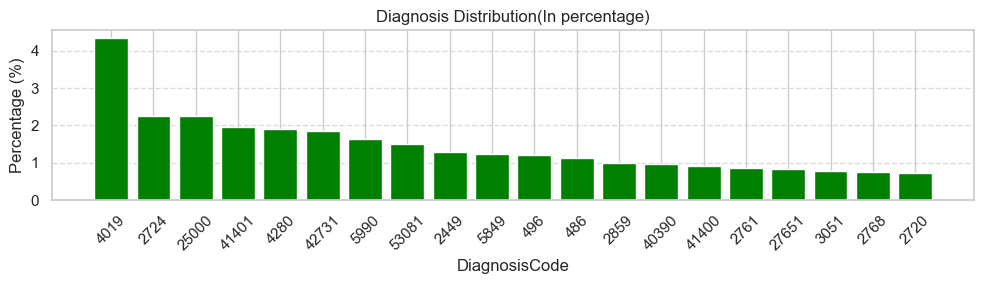

In [615]:
# Automatically grabs ClmDiagnosisCode_1 through ClmDiagnosisCode_10
diag_cols = data_inpatient.filter(like='ClmDiagnosisCode').columns

# Concatenate into a single Series and remove missing values
inpatient_diag_df = pd.DataFrame(
    pd.concat([data_inpatient[col] for col in diag_cols], axis=0).dropna(),
    columns=['DiagnosisCode']
)
analyse_cat_columns(inpatient_diag_df,col_to_analyse='DiagnosisCode' , title = 'Diagnosis Distribution(In percentage)',top_val = 20, color ='green')


# Outpatient Records Data Analysis

### Outpatient Data - In healthcare analytics, Outpatient Data refers to medical services provided to patients who are not admitted to a hospital (stays lasting less than 24 hours). This dataset is typically much larger and more "noisy" than inpatient data because it covers a vast range of routine interactions.

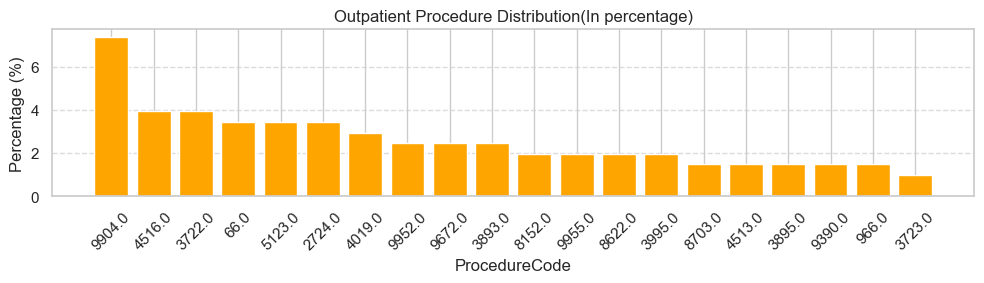

In [616]:
# Select all columns that start with 'ClmProcedureCode'
proc_cols = [col for col in data_outpatient.columns if 'ClmProcedureCode' in col]

# Concatenate them all and drop NaNs
outpatient_df = pd.DataFrame(
    pd.concat([data_outpatient[col] for col in proc_cols], axis=0).dropna(),
    columns=['ProcedureCode']
)
analyse_cat_columns(outpatient_df,col_to_analyse='ProcedureCode' ,title = 'Outpatient Procedure Distribution(In percentage)',top_val = 20, color='orange')

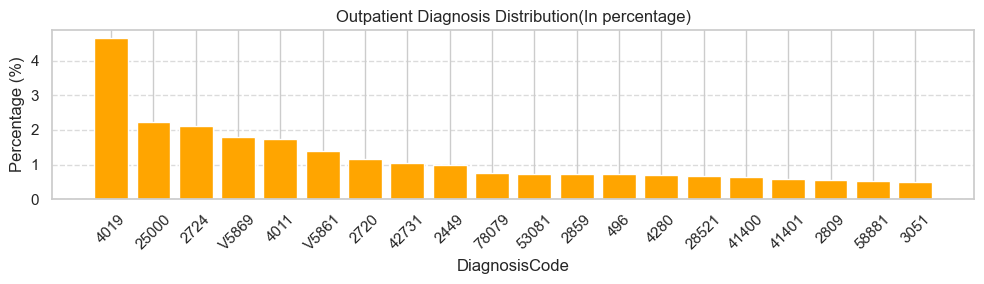

In [617]:
# Automatically grabs ClmDiagnosisCode_1 through ClmDiagnosisCode_10
diag_cols = data_outpatient.filter(like='ClmDiagnosisCode').columns

# Concatenate into a single Series and remove missing values
outpatient_diag_df = pd.DataFrame(
    pd.concat([data_outpatient[col] for col in diag_cols], axis=0).dropna(),
    columns=['DiagnosisCode']
)
analyse_cat_columns(outpatient_diag_df,col_to_analyse='DiagnosisCode' , title = 'Outpatient Diagnosis Distribution(In percentage)',top_val = 20, color='orange')

# 2 . Physician Analysis on number of claims

Why this is critical for Fraud, Waste, and Abuse (FWA)
Identification of "Super-Billers": If one physician is filing significantly more claims than their peers, it could indicate "Phantom Billing" (billing for patients they never actually saw) or "Churning" (requiring unnecessary follow-up visits).

Capacity Analysis: In some fraud cases, data mining reveals that a single physician "performed" more surgeries in a 24-hour period than is humanly possible. This visualization helps spot those "impossible" volumes.

Audit Prioritization: Instead of auditing every provider, investigators use this specific list to prioritize "High-Yield" audits—focusing where the most money (and potentially the most fraud) is concentrated.

Attending Physician: The doctor who has primary responsibility for the patient's care and treatment during the entire hospital stay or clinic visit. They "own" the patient's record and oversee the overall medical plan.

Operating Physician: The specific doctor who performs a surgical or non-surgical procedure. In many outpatient cases, the Attending and Operating physician are the same person, but in complex cases, they differ.

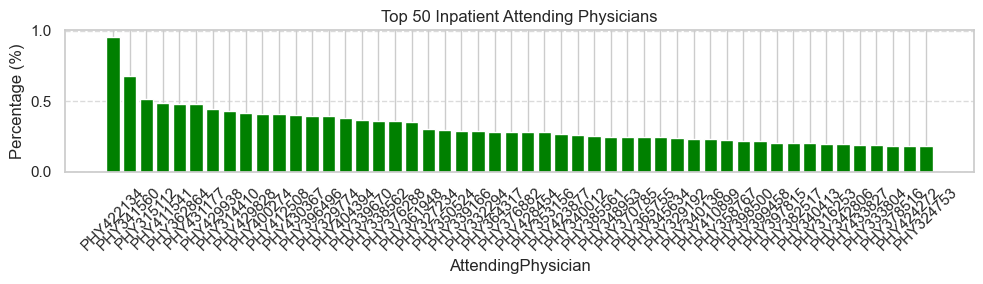

In [618]:
# Analyse Attending Physicians in Inpatient Data

analyse_cat_columns(data_inpatient, 
                    col_to_analyse='AttendingPhysician', 
                    title='Top 50 Inpatient Attending Physicians', 
                    top_val=50, 
                    color='green')

# Conclusion

#### Analysis of the Attending Physician distribution reveals a high concentration of claims among the top 20 providers. In a fraud detection context, these 'Super-Billers' represent the highest financial risk. Further investigation is required to determine if their high volume is justified by their specialty or if it represents an anomaly such as excessive service utilization (Waste) or fictitious billing (Fraud).
#### Most patients are attended by physician PHY422134. Around 1% of the patients are attended by physician PHY422134

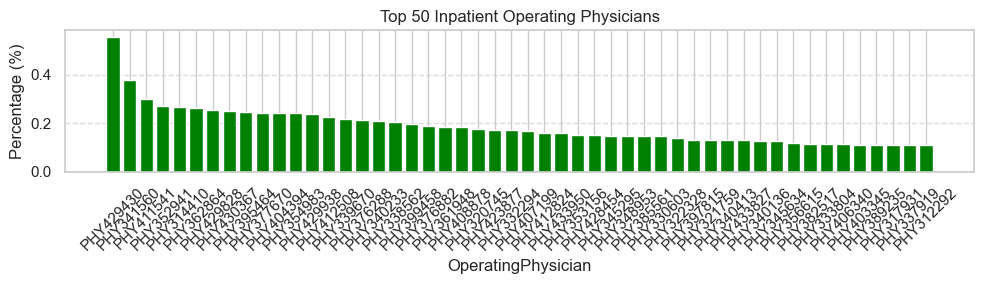

In [619]:
# Analyse Operating Physicians in Inpatient Data

analyse_cat_columns(data_inpatient, 
                    col_to_analyse='OperatingPhysician', 
                    title='Top 50 Inpatient Operating Physicians', 
                    top_val=50, 
                    color='green')

# Conclusion

#### Most patients are operated by physician PHY429430. Around 0.55% of the patients are operated by physician PHY429430

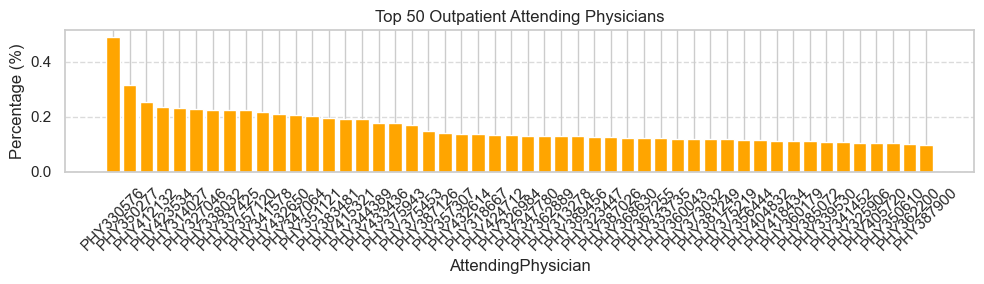

In [620]:
# Analyse Attending Physicians in Outpatient Data

analyse_cat_columns(data_outpatient, 
                    col_to_analyse='AttendingPhysician', 
                    title='Top 50 Outpatient Attending Physicians', 
                    top_val=50, 
                    color='orange')

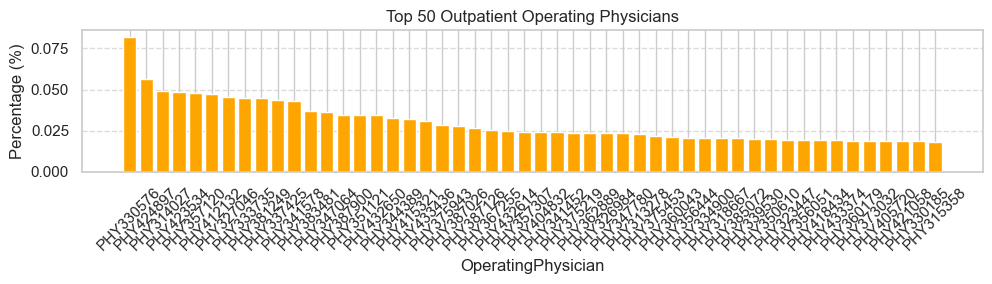

In [621]:
# Analyse Operating  Physicians in Outpatient Data

analyse_cat_columns(data_outpatient, 
                    col_to_analyse='OperatingPhysician', 
                    title='Top 50 Outpatient Operating Physicians', 
                    top_val=50, 
                    color='orange')

# Conclusion

#### Most patients are operated by physician PHY330576 and attending provider is also same which a legit scenario is Outpatient claims

In [622]:
# Analyzing the relationship between these two roles allows us to detect sophisticated fraud schemes:
# An Attending Physician consistently refers patients to the same Operating Physician for unnecessary surgeries.

# To analyze these together, we can create a "Pairing" feature in Python. This helps find "Closed Loops"
#  where two doctors are working together suspiciously often.

# Also for Outpatient claims mostly Attending and Operating physicians are same.

# Create a unique 'Team' ID for every claim
data_outpatient['Physician_Team'] = (
    data_outpatient['AttendingPhysician'] + "_" + data_outpatient['OperatingPhysician']
)

# Find the most common teams
top_teams = data_outpatient['Physician_Team'].value_counts().head(10)
#print(top_teams)

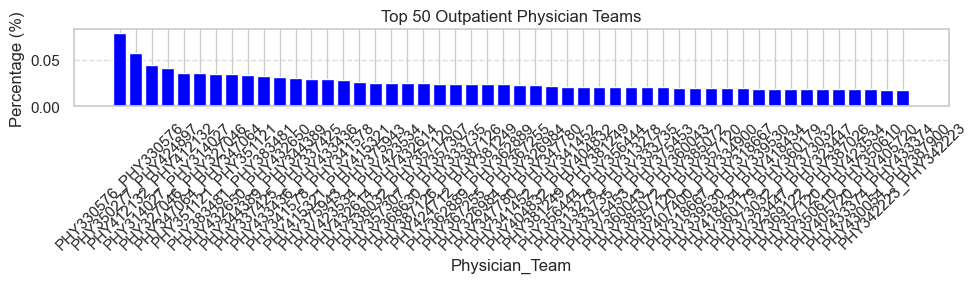

In [623]:
analyse_cat_columns(data_outpatient, 
                    col_to_analyse='Physician_Team', 
                    title='Top 50 Outpatient Physician Teams', 
                    top_val=50, 
                    color='blue')

# Conclusion

#### The top combination is legit one where attending and operating physician providers are same. For others where they are different data needs to be analyzed.

# 3 . Analysis of Claim Amount Reimbursed

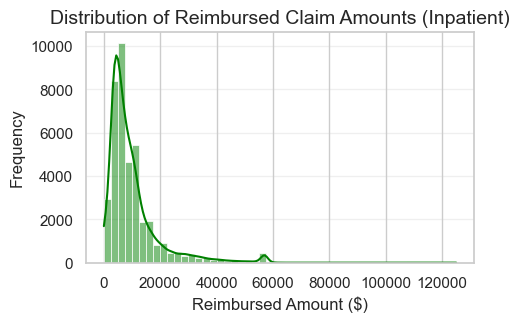

In [624]:
# Checking distribution of Claim amount for Inpatient Claims

plt.figure(figsize=(5, 3))
# Using histplot for a more modern, detailed view
sns.histplot(data_inpatient['InscClaimAmtReimbursed'], kde=True, color='green', bins=50)

plt.title('Distribution of Reimbursed Claim Amounts (Inpatient)', fontsize=14)
plt.xlabel('Reimbursed Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Conclusion

#### Right Skewness: Amount distribution is heavily "right-skewed," meaning the majority of claims are for small amounts, with a few very expensive outliers (like major surgeries).
#### Outliers: Claims that fall far to the right of the tail are the "High-Dollar" risks. These require the most scrutiny because a single fraudulent high-dollar claim can cause more damage than hundreds of small ones.

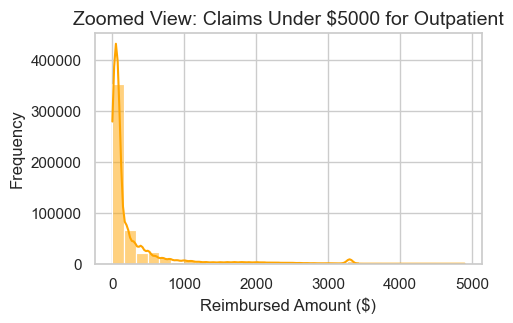

In [625]:
# Checking distribution of Claim amount for Outpatient Claims

# Create a temporary view of only small claims
small_claims = data_outpatient[data_outpatient['InscClaimAmtReimbursed'] < 5000]

plt.figure(figsize=(5, 3))
sns.histplot(small_claims['InscClaimAmtReimbursed'], kde=True, color='orange', bins=30)

plt.title('Zoomed View: Claims Under $5000 for Outpatient', fontsize=14)
plt.xlabel('Reimbursed Amount ($)')
plt.ylabel('Frequency')
plt.show()

# Conclusion

#### The distribution of Outpatient Reimbursed Amounts exhibits extreme right-skewness, with the vast majority of claims falling below $1000. The presence of claims reaching up to $3000 indicates a small subset of high-cost outpatient procedures. For FWA detection, these high-dollar outliers should be cross-referenced with Provider IDs to determine if a single provider is disproportionately responsible for these expensive claims

# Here are the high-level conclusions we can derive by connecting three data points (codes, amount and Provider): (which can change in future based on further analysis)

#### Identifying "Upcoding" Patterns (Codes + Amounts) - By correlating Procedure Codes with the Reimbursed Amount, we can determine if a provider is billing for high-intensity services (like complex surgeries) when the diagnosis only supports a minor intervention. 
#### Conclusion: If the average reimbursement for a specific provider is significantly higher than the peer mean for the same procedure code, it indicates potential Upcoding or the unbundling of services to inflate the claim.


#### Detection of "Impossible Volume" (Provider + Claims) - Analysis of the top-billing providers (like "Super-Biller" PHY422134) allows us to perform a capacity check.
#### Conclusion: If a provider's claim count exceeds the 99th percentile of their peer group, they are a high-risk outlier. If the number of procedures billed in a 24-hour window exceeds human capacity, we have a strong indicator of Phantom Billing (billing for services never rendered).


#### Specialization Anomaly (Codes + Provider) - By looking at which codes a specific provider uses most, we can spot "out-of-specialty" billing.
#### Conclusion: If a General Practitioner (Attending Physician) is consistently appearing as the Operating Physician for highly specialized codes (like 3722 - Heart Surgery), it flags a major Credentialing Fraud or Scope of Practice violation.

## We will not try to go in details of service codes, procedure code and specialty related to Provider. Our focus will be based on the dataset we have. But this also can be check to reduce FWA in Healthcare industry.




# Milestone 2 **************************************************************************************** 
# Term Project Milestone 2: Data Preparation

Here is a list of steps to consider performing in Milestone 2:



* Drop any features that are not useful for your model building and explain why they are not useful.
* Perform any data extraction/selection steps.
* Transform features if necessary.
* Engineer new useful features.
* Deal with missing data (do not just drop rows or columns without justifying this).
* Create dummy variables if necessary.


We need to complete some more EDA for the project

# 4 . Analysis of Labeled data

In [626]:
#check all the columns of the labeled  dataset and top 5 data points
print('Columns in this dataset are : ')
print(data.columns)

data.head(5)

Columns in this dataset are : 
Index(['Provider', 'PotentialFraud'], dtype='object')


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


<Axes: xlabel='PotentialFraud', ylabel='count'>

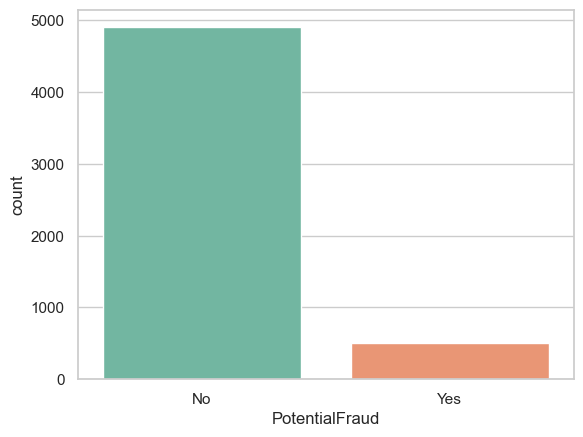

In [627]:
# Check the distribution of the target variable
sns.countplot(x='PotentialFraud',data=data, palette='Set2')

# Conclusion
Dataset is imbalanced


# 5a . Percentage of fraudulent encounters Inpatient / Outpatient

In [628]:
# Now we will filter out only the fraudulent providers to analyze their characteristics in more detail.

only_fraud_provider = data.loc[data['PotentialFraud']=='Yes']
print("Dataset shape : ", only_fraud_provider.shape)
only_fraud_provider.head(5)

Dataset shape :  (506, 2)


,Provider,PotentialFraud
1,PRV51003,Yes
3,PRV51005,Yes
13,PRV51021,Yes
25,PRV51037,Yes
37,PRV51052,Yes


In [629]:
# Now we will merge this dataset with the Inpatient and Outpatient datasets to analyze the characteristics of fraudulent providers in more detail.

fraud_provider_inpatient_df = pd.merge(data_inpatient, only_fraud_provider, how='inner', on='Provider')
print("Dataset shape : ", fraud_provider_inpatient_df.shape)
#fraud_provider_inpatient_df.head(5)

Dataset shape :  (23402, 31)


In [630]:
# Now we will check what percentage of the inpatient data is related to fraudulent providers.

print("Dataset shape : ", fraud_provider_inpatient_df.shape)
print("Percentage of fraud cases related to inpatient data : ",(fraud_provider_inpatient_df.shape[0]/data_inpatient.shape[0])*100)

Dataset shape :  (23402, 31)
Percentage of fraud cases related to inpatient data :  57.81983495577408


# Conclusion
Around 58 % of the inpatient data for training has fraudulent encounter

In [631]:
# Now we will check what percentage of the outpatient data is related to fraudulent providers.

fraud_provider_outpatient_df = pd.merge(data_outpatient, only_fraud_provider, how='inner', on='Provider')
print("Dataset shape : ", fraud_provider_outpatient_df.shape)
#fraud_provider_outpatient_df.head(5)

Dataset shape :  (189394, 29)


In [632]:
# Now we will check what percentage of the outpatient data is related to fraudulent providers.

print("Dataset shape : ", fraud_provider_outpatient_df.shape)
print("Percentage of fraud cases related to outpatient data : ",(fraud_provider_outpatient_df.shape[0]/data_outpatient.shape[0])*100)

Dataset shape :  (189394, 29)
Percentage of fraud cases related to outpatient data :  36.58112130290089


# Conclusion
Around 37 % of the outpatient data for training has fraudulent encounter

# 5b . 20 Most used procedure codes and diagnosis codes used by the potential fraudulent providers
# Inpatient - Procedure

(17325, 1)


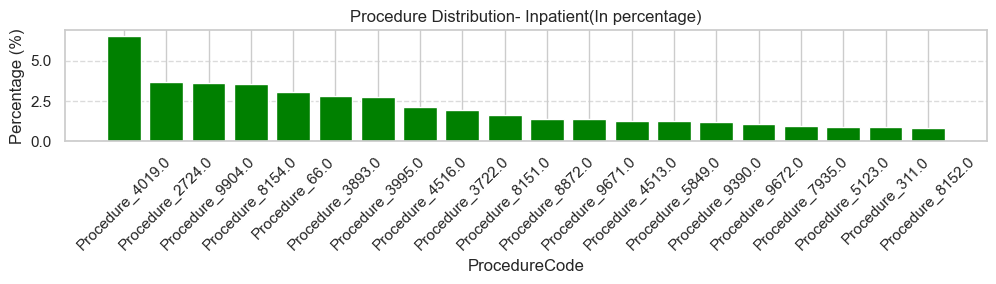

In [633]:
#create a dataframe for concatenating all Procedure Code columns  

inpatient_df = pd.DataFrame(columns = ['ProcedureCode'])
inpatient_df['ProcedureCode'] = pd.concat([fraud_provider_inpatient_df["ClmProcedureCode_1"], 
                                           fraud_provider_inpatient_df["ClmProcedureCode_2"],
                                           fraud_provider_inpatient_df["ClmProcedureCode_3"],
                                           fraud_provider_inpatient_df["ClmProcedureCode_4"], 
                                           fraud_provider_inpatient_df["ClmProcedureCode_5"], 
                                           fraud_provider_inpatient_df["ClmProcedureCode_6"]], axis=0, sort=True).dropna()

print(inpatient_df.shape)

analyse_cat_columns(inpatient_df,col_to_analyse='ProcedureCode' , prefix = 'Procedure_',title = 'Procedure Distribution- Inpatient(In percentage)',top_val = 20)

(189329, 1)


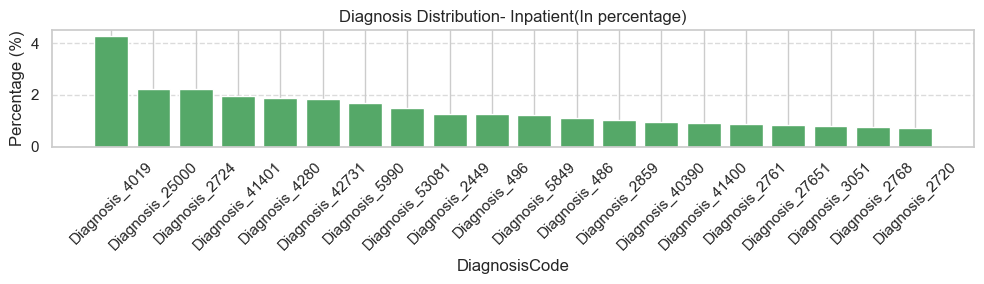

In [634]:
#create a dataframe for concatenating all DiagnosisCode Code columns  

inpatient_df = pd.DataFrame(columns = ['DiagnosisCode'])
inpatient_df['DiagnosisCode'] = pd.concat([fraud_provider_inpatient_df["ClmDiagnosisCode_1"], 
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_2"], 
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_3"], 
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_4"],
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_5"], 
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_6"],
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_7"],
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_8"],
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_9"],
                                           fraud_provider_inpatient_df["ClmDiagnosisCode_10"]], axis=0, sort=True).dropna()

print(inpatient_df.shape)

analyse_cat_columns(inpatient_df,col_to_analyse='DiagnosisCode' , prefix = 'Diagnosis_',title = 'Diagnosis Distribution- Inpatient(In percentage)',top_val = 20 ,color = 'g')

(96, 1)


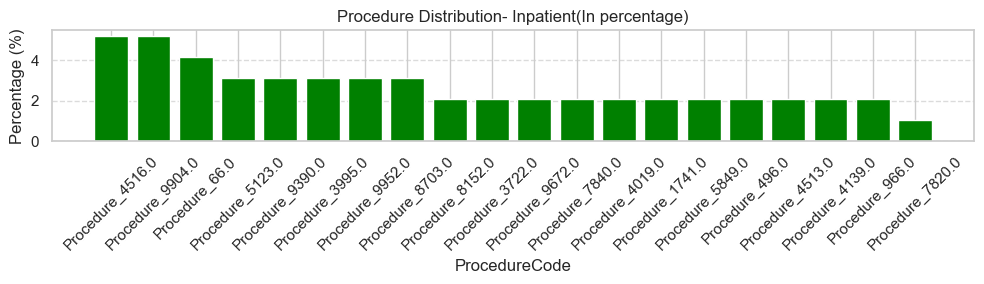

In [635]:
#create a dataframe for concatenating all Procedure Code columns  

inpatient_df = pd.DataFrame(columns = ['ProcedureCode'])
inpatient_df['ProcedureCode'] = pd.concat([fraud_provider_outpatient_df["ClmProcedureCode_1"], 
                                           fraud_provider_outpatient_df["ClmProcedureCode_2"],
                                           fraud_provider_outpatient_df["ClmProcedureCode_3"],
                                           fraud_provider_outpatient_df["ClmProcedureCode_4"], 
                                           fraud_provider_inpatient_df["ClmProcedureCode_5"], 
                                           fraud_provider_outpatient_df["ClmProcedureCode_6"]], axis=0, sort=True).dropna()

print(inpatient_df.shape)

analyse_cat_columns(inpatient_df,col_to_analyse='ProcedureCode' , prefix = 'Procedure_',title = 'Procedure Distribution- Inpatient(In percentage)',top_val = 20)

(494869, 1)


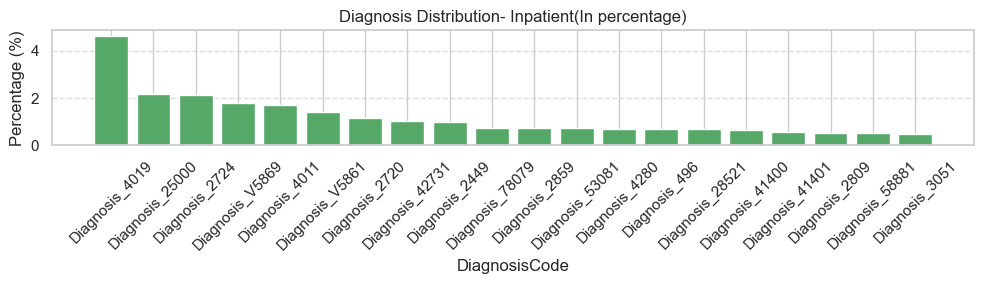

In [636]:
#create a dataframe for concatenating all DiagnosisCode Code columns  

inpatient_df = pd.DataFrame(columns = ['DiagnosisCode'])
inpatient_df['DiagnosisCode'] = pd.concat([fraud_provider_outpatient_df["ClmDiagnosisCode_1"], 
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_2"], 
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_3"], 
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_4"],
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_5"], 
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_6"],
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_7"],
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_8"],
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_9"],
                                           fraud_provider_outpatient_df["ClmDiagnosisCode_10"]], axis=0, sort=True).dropna()

print(inpatient_df.shape)

analyse_cat_columns(inpatient_df,col_to_analyse='DiagnosisCode' , prefix = 'Diagnosis_',title = 'Diagnosis Distribution- Inpatient(In percentage)',top_val = 20 ,color = 'g')

# 6a . State and County

In [637]:
# Now we will merge the beneficiary dataset with the inpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

bene_inpat_df = pd.merge(data_beneficiary, fraud_provider_inpatient_df, how='inner', on='BeneID')
print(bene_inpat_df.shape)
bene_inpat_df.head(5)

(23402, 55)


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,PotentialFraud
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
1,BENE11017,1940-06-01,NaN,2,1,0,31,270,12,12,...,25000,25002,NaN,863.0,NaN,NaN,NaN,NaN,NaN,Yes
2,BENE11028,1941-12-01,NaN,1,1,0,38,230,12,12,...,4439,41401,NaN,9904.0,NaN,NaN,NaN,NaN,NaN,Yes
3,BENE11034,1946-03-01,NaN,2,1,0,34,760,12,12,...,4111,4589,NaN,3612.0,4139.0,NaN,NaN,NaN,NaN,Yes
4,BENE11034,1946-03-01,NaN,2,1,0,34,760,12,12,...,591,51881,NaN,9672.0,NaN,NaN,NaN,NaN,NaN,Yes


<Axes: xlabel='State', ylabel='count'>

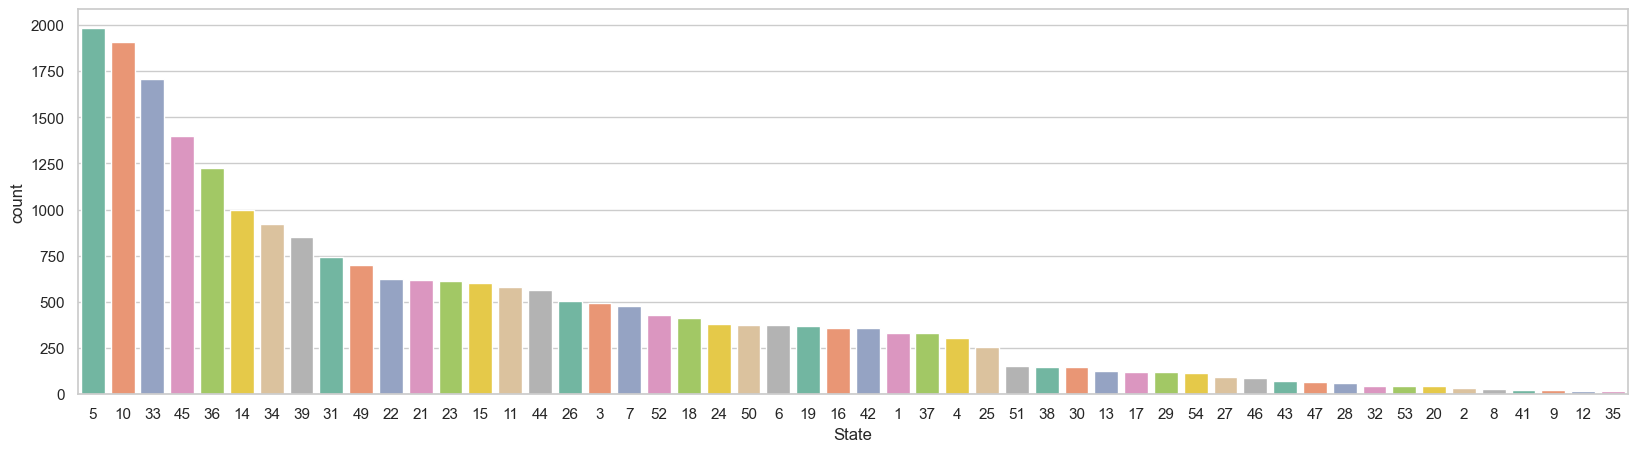

In [638]:
# Now we will merge the beneficiary dataset with the inpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

plt.figure(figsize=(20, 5))
sns.countplot(x='State',y=None, data=bene_inpat_df, orient ="v", order = bene_inpat_df['State'].value_counts().index, palette='Set2')

<Axes: xlabel='County', ylabel='count'>

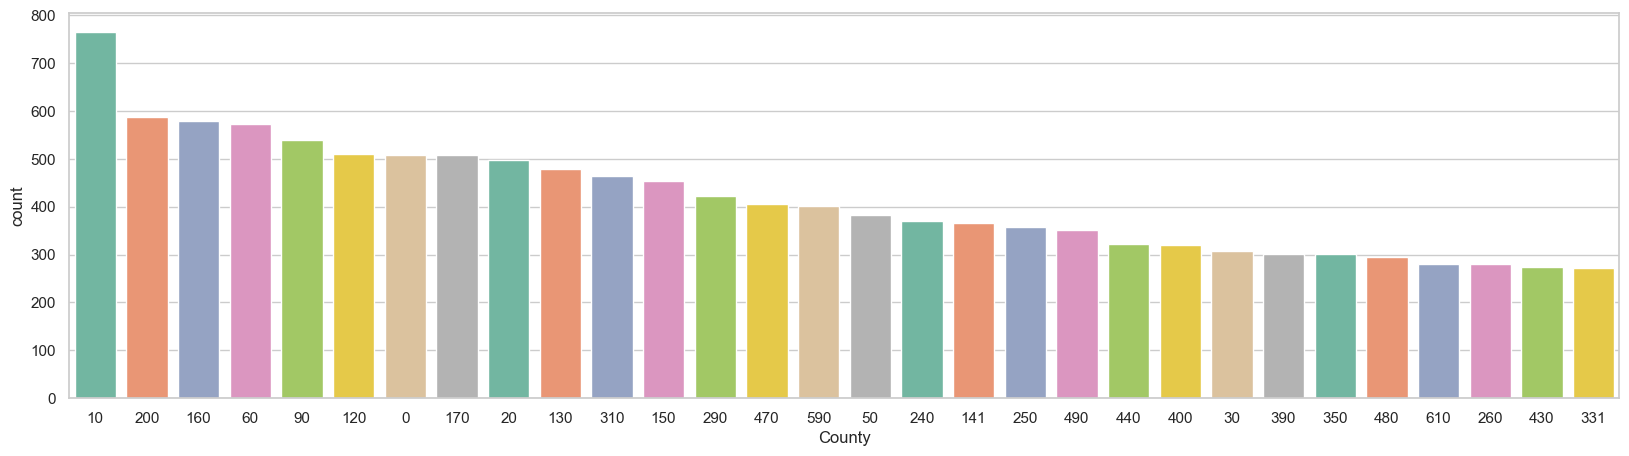

In [639]:
# Now we will merge the beneficiary dataset with the inpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.
plt.figure(figsize=(20, 5))
sns.countplot(x='County',y=None, data=bene_inpat_df, orient ="v", order = bene_inpat_df['County'].value_counts().head(30).index, palette='Set2')

# Conclusion
### Inpatient + fraud -- State
State coded as 5,10,33 and 45 have most fraudulent encounters for Inpatient data .
County coded as 10,200,160 and 60 have most fraudulent encounters for Inpatient data .

# Outpatient + Fraud -- State

In [640]:
# Now we will merge the beneficiary dataset with the outpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

bene_outpat_df = pd.merge(data_beneficiary, fraud_provider_outpatient_df, how='inner', on='BeneID')
print(bene_outpat_df.shape)
#bene_outpat_df.head(5)

(189394, 53)


<Axes: xlabel='State', ylabel='count'>

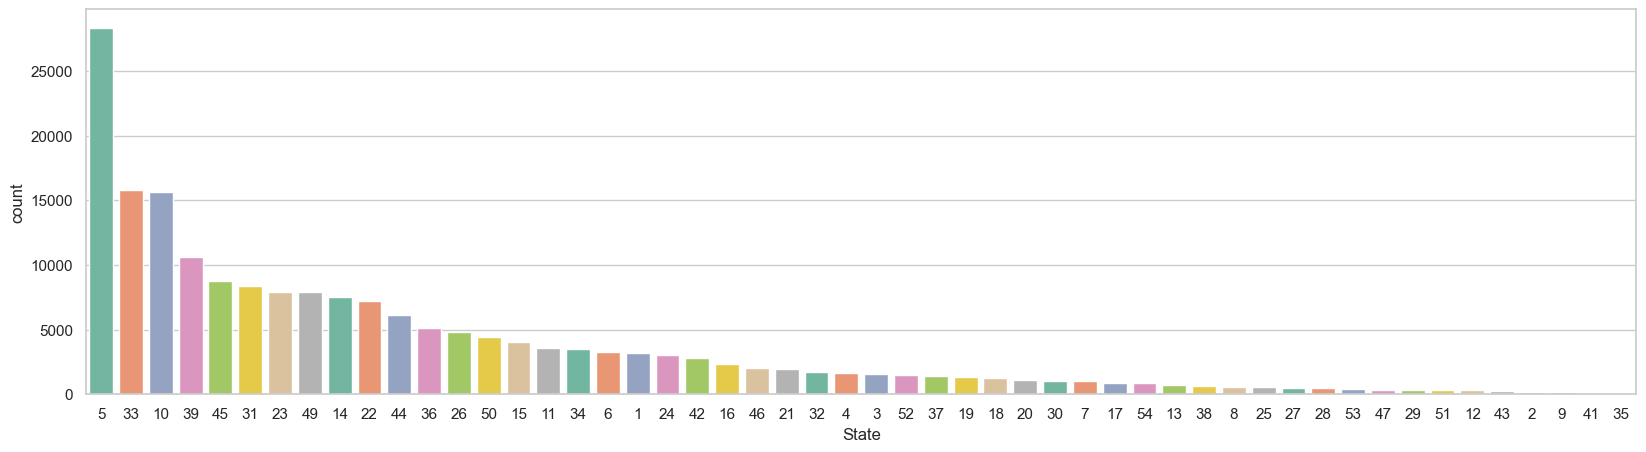

In [641]:
# Now we will merge the beneficiary dataset with the outpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

plt.figure(figsize=(20, 5))
sns.countplot(x='State',y=None, data=bene_outpat_df, orient ="v", order = bene_outpat_df['State'].value_counts().index, palette='Set2')

<Axes: xlabel='County', ylabel='count'>

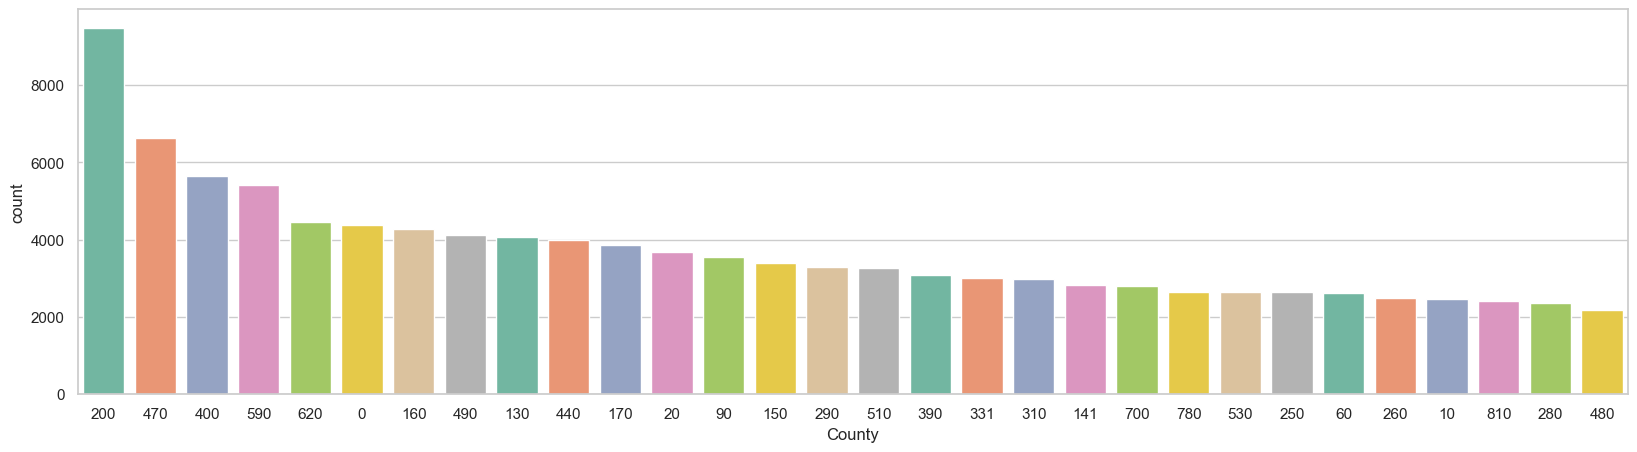

In [642]:
# Now we will merge the beneficiary dataset with the outpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

plt.figure(figsize=(20, 5))
sns.countplot(x='County',y=None, data=bene_outpat_df, orient ="v", order = bene_outpat_df['County'].value_counts().head(30).index, palette='Set2')

# Conclusion
### Outpatient + fraud -- State 

State coded as 5,33,10 and 39 have most fraudulent encounters for Inpatient data.
County coded as 200,470,400 and 590 have most fraudulent encounters for Outpatient data .

# 6b . DOB

## Inpatient + Fraud - DOB

<Axes: xlabel='DOB', ylabel='Count'>

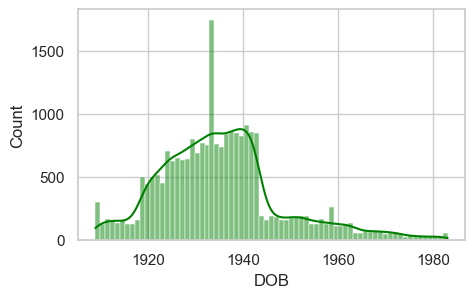

In [643]:
# Ensure DOB is a datetime type (if not already)
bene_inpat_df['DOB'] = pd.to_datetime(bene_inpat_df['DOB'])

# histogram of birth years to see the age distribution of beneficiaries associated with fraudulent providers
plt.figure(figsize=(5, 3))
sns.histplot(bene_inpat_df.DOB.apply(get_year), kde=True, color='green')

# Conclusion
### Inpatient + Fraud - DOB

Most Fraudulent encounters in Inpatient Data is observed for the patients born between 1920 and 1945

## Outpatient + Fraud - DOB

<Axes: xlabel='DOB', ylabel='Count'>

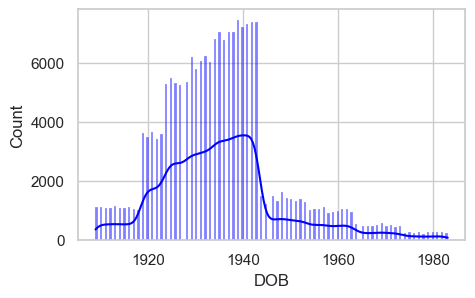

In [644]:
# Ensure DOB is a datetime type (if not already)
bene_outpat_df['DOB'] = pd.to_datetime(bene_outpat_df['DOB'])

# histogram of birth years to see the age distribution of beneficiaries associated with fraudulent providers
plt.figure(figsize=(5, 3))
sns.histplot(bene_outpat_df.DOB.apply(get_year), kde=True, color='blue')

# Conclusion
### Outpatient + Fraud - DOB

Most Fraudulent encounters in Inpatient Data is observed for the patients born between 1920 and 1945

# 7.  Calculating Money lost in Fraud for both Inpatient and outpatinet data

In [645]:
# Now we will merge the beneficiary dataset with the inpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

inpat_labeled_provider_df = pd.merge(data_inpatient , data , how='inner', on='Provider')
print(inpat_labeled_provider_df.shape)

(40474, 31)


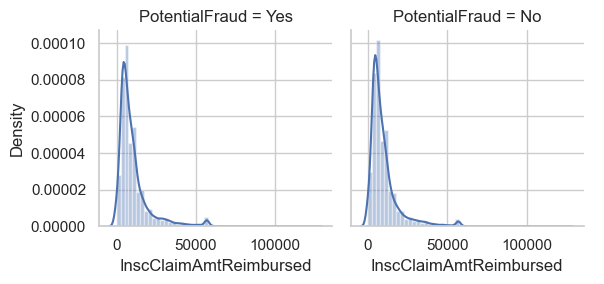

<Figure size 640x480 with 0 Axes>

In [646]:
# Now we will merge the beneficiary dataset with the inpatient dataset to analyze the characteristics of beneficiaries related to 
# fraudulent providers in more detail.

sns.FacetGrid(inpat_labeled_provider_df, col='PotentialFraud',height=3).map(sns.distplot, "InscClaimAmtReimbursed",).add_legend()
plt.show()
plt.tight_layout()

In [647]:
# calculating total money lost inpatient fraudulent encounters

Total_money_lost = inpat_labeled_provider_df.loc[inpat_labeled_provider_df['PotentialFraud']== 'Yes'].InscClaimAmtReimbursed.sum()

print("Total money lost : ",Total_money_lost)

Total money lost :  241288510


In [648]:
# calculating total money lost outpatient fraudulent encounters 

outpat_labeled_provider_df = pd.merge(data_outpatient , data , how='inner', on='Provider')
print(outpat_labeled_provider_df.shape)

(517737, 29)


In [649]:
# calculating total money lost in outpatient fraudulent encounters
Total_money_lost = outpat_labeled_provider_df.loc[outpat_labeled_provider_df['PotentialFraud']== 'Yes'].InscClaimAmtReimbursed.sum()

print("Total money lost : ",Total_money_lost)

Total money lost :  54392610


In [650]:
print('Total money lost as per the data = ','241,288,510 + 54,392,610, That is around 295 Million' )

Total money lost as per the data =  241,288,510 + 54,392,610, That is around 295 Million


Till this point we have done thorough EDA on columns of each of the data files. Now we will merge them all and then perform EDA to establish a trend in data and the target.

# 8 . Data preprocessing and Feature Engineering

In [651]:
# Create a binary target variable for whether the claim was admitted (inpatient) or not (outpatient)

data_inpatient['is_admitted'] = 1
data_outpatient['is_admitted'] = 0

In [652]:
# Merge in_pt, out_pt and ben df into a single patient dataset
data1 = pd.merge(data_inpatient, data_outpatient,
                    left_on = [ idx for idx in data_outpatient.columns if idx in data_inpatient.columns],
                    right_on = [ idx for idx in data_outpatient.columns if idx in data_inpatient.columns],
                    how = 'outer').\
          merge(data_beneficiary,left_on='BeneID',right_on='BeneID',how='inner')


In [653]:
# Replace values with a binary annotation

data1 = data1.replace({'ChronicCond_Alzheimer': 2, 'ChronicCond_Heartfailure': 2, 'ChronicCond_KidneyDisease': 2,
                   'ChronicCond_Cancer': 2, 'ChronicCond_ObstrPulmonary': 2, 'ChronicCond_Depression': 2,
                   'ChronicCond_Diabetes': 2, 'ChronicCond_IschemicHeart': 2, 'ChronicCond_Osteoporasis': 2,
                   'ChronicCond_rheumatoidarthritis': 2, 'ChronicCond_stroke': 2, 'Gender': 2 }, 
                  0)

In [654]:
# data1.RenalDiseaseIndicator.unique() #array(['0', 'Y'], dtype=object)
# Replace values with a binary annotation

data1 = data1.replace({'RenalDiseaseIndicator': 'Y'}, 1).astype({'RenalDiseaseIndicator': 'int64'})#array([0, 1], dtype=int64)

In [655]:
#merging the dataset created in above step with data
data_final = pd.merge(data1, data , how = 'outer', on = 'Provider' )

In [656]:
# adding extra column target, having binary annotation
data_final['target'] = data_final['PotentialFraud']

# representing potential fraud and 0 representing non potential fraud
data_final['target'] = data_final['target'].map({"Yes":1,"No":0})
data_final['target'] = data_final['target'].astype('category',copy=False)

PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64


<Axes: xlabel='PotentialFraud', ylabel='count'>

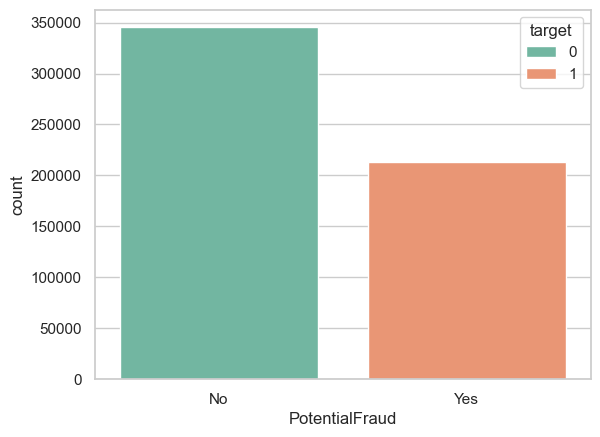

In [657]:
# checking the distribution of target variable in the final dataset

print(data_final.PotentialFraud.value_counts())
sns.countplot(x='PotentialFraud', data=data_final, palette='Set2', hue='target') 

In [658]:
# Now we have a final dataset with all the features from inpatient, outpatient and beneficiary datasets, 
# along with the target variable indicating potential fraud. We can now proceed to build machine learning models to predict fraudulent providers based on these features.

print(data_final.shape)
data_final.head(5)

(558211, 58)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,target
0,BENE102690,CLM49733,2009-05-04,2009-05-18,PRV51001,42000,PHY383193,PHY378091,PHY389113,2009-05-04,...,1,0,1,0,143800,4272,880,70,No,0
1,BENE106078,CLM419490,2009-06-16,2009-06-16,PRV51001,90,PHY345302,NaN,NaN,NaN,...,1,0,0,0,0,0,190,20,No,0
2,BENE11727,CLM733300,2009-12-17,2009-12-17,PRV51001,20,PHY383007,NaN,PHY383007,NaN,...,1,0,0,0,0,0,300,110,No,0
3,BENE123416,CLM172987,2009-02-02,2009-02-02,PRV51001,100,PHY345302,NaN,PHY345302,NaN,...,1,0,0,0,0,0,3600,10,No,0
4,BENE126477,CLM361230,2009-05-15,2009-05-15,PRV51001,200,PHY354616,PHY405310,PHY405310,NaN,...,1,0,1,0,0,0,690,150,No,0


In [659]:

#Adding a column is_dead  = 1  DOD is given else is_dead = 0 

data_final.loc[data_final['DOD'].isnull(), 'Is_Dead'] = '0'
data_final.loc[(data_final['DOD'].notnull()), 'Is_Dead'] = '1'


As we have DOD for only few BeneID,so we can only determine the eaxct age of the patinets who has died.we cannot get the age of the patonets who might be alive.So its better that we calculate the age of the patient when we submiited his claim as we have record for ClaimStartDt

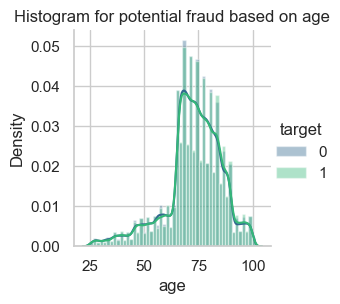

<Figure size 640x480 with 0 Axes>

In [660]:
# Now we will analyze the age distribution of beneficiaries associated with fraudulent providers. 
# We will calculate the age of beneficiaries at the time of claim and plot the distribution of age for potential fraud and non potential fraud cases.

data_final['DOB'] =  pd.to_datetime(data_final['DOB'], format='%Y-%m-%d')  
data_final['ClaimStartDt'] = pd.to_datetime(data_final['ClaimStartDt'], format='%Y-%m-%d')  

#now = pd.to_datetime('2020-09-01' , format = '%Y-%m-%d')
data_final['DOB'] = data_final['DOB'].where(data_final['DOB'] < data_final['ClaimStartDt']) 
#data_final['age'] = (data_final['ClaimStartDt'] - data_final['DOB']).astype('<m8[Y]')
data_final['age'] = (data_final['ClaimStartDt'] - data_final['DOB']).dt.days // 365


#plotting age
sns.FacetGrid(data_final, hue="target" , height=3, palette='viridis').map(sns.distplot, "age",).add_legend()
plt.title('Histogram for potential fraud based on age')
plt.show()
plt.tight_layout()

# Conclusion
# Age
* We don't see any difference in distribution of age that may enable us to flag potential fraud.
* But we see increasing trend in the potential fraud cases for patients age > 65 Also most of the patient who applied for claim fall in this age range only.
* For our analysis we will drop the DOB and DOD.

Text(0.5, 1.0, 'Plot to Analyse relation between Race and fraud/not fraud')

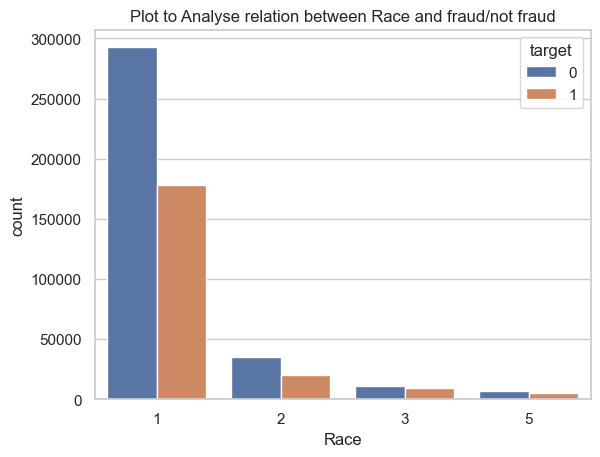

In [661]:
# Now we will analyze the relationship between Race and potential fraud cases in the dataset.

ax = sns.countplot(x='Race',data=data_final,hue='target')
ax.set_title("Plot to Analyse relation between Race and fraud/not fraud")

# Conclusion

It is very important to see that most fraudulent cases is with patients belonging to a particular Race and that is labelled as 1


In [662]:
# Since we didn't have any use for DOD and DOB columns in our analysis, we will drop these columns from the final dataset.

data_final = data_final.drop(['DOD'], axis = 1)
data_final = data_final.drop(['DOB'], axis = 1)

In [663]:
#calculating number of days a patient was admitted in the hospital and then removing admit and discharge date
#outpatients dont get admitted so we keep 0 for them


data_final['AdmissionDt'] = pd.to_datetime(data_final['AdmissionDt'] , format = '%Y-%m-%d')
data_final['DischargeDt'] = pd.to_datetime(data_final['DischargeDt'],format = '%Y-%m-%d')
data_final['Num_admit_days'] = ((data_final['DischargeDt'] - data_final['AdmissionDt']).dt.days)+1
data_final.loc[data_final['is_admitted'] == 0, 'Num_admit_days'] = '0'

data_final = data_final.drop(['DischargeDt'], axis = 1)
data_final = data_final.drop(['AdmissionDt'], axis = 1)

In [664]:
#replacing NaN value with 0
data_final.loc[data_final['DeductibleAmtPaid'].isnull(),'DeductibleAmtPaid'] = 0

<Axes: title={'center': 'Top 5 suspicious Diagnosis'}, xlabel='DiagnosisCode'>

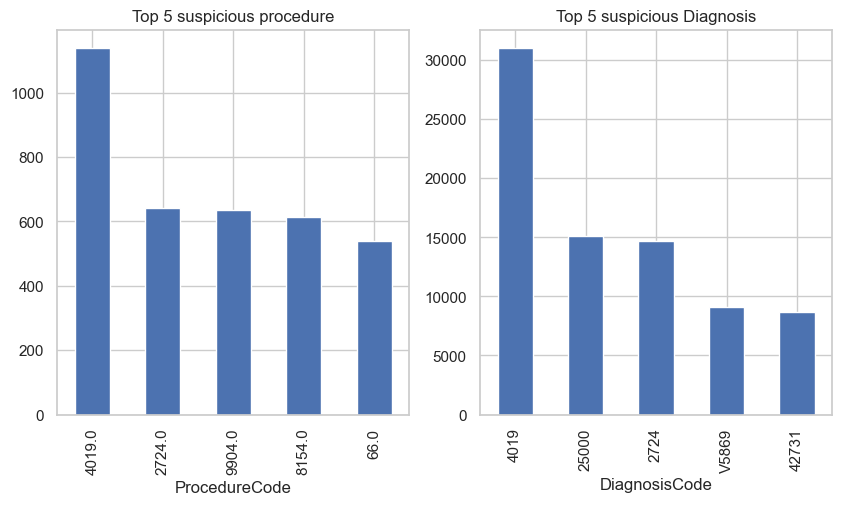

In [665]:
# Now we will analyze the top procedure codes and diagnosis codes associated with potential fraud cases in the dataset.
# We will concatenate all the procedure code columns and diagnosis code columns into two separate dataframes 
# and then plot the top 5 procedure codes and diagnosis codes associated with potential fraud cases in the dataset.

potential_fraud_df =data_final.loc[data_final['PotentialFraud'] == 'Yes']

df1 = pd.DataFrame(columns = ['ProcedureCode'])
df1['ProcedureCode'] = pd.concat([potential_fraud_df["ClmProcedureCode_1"], 
                                           potential_fraud_df["ClmProcedureCode_2"],
                                           potential_fraud_df["ClmProcedureCode_3"],
                                           potential_fraud_df["ClmProcedureCode_4"], 
                                           potential_fraud_df["ClmProcedureCode_5"], 
                                           potential_fraud_df["ClmProcedureCode_6"]], axis=0, sort=True).dropna()

df2 = pd.DataFrame(columns = ['DiagnosisCode'])
df2['DiagnosisCode'] = pd.concat([potential_fraud_df["ClmDiagnosisCode_1"], 
                                           potential_fraud_df["ClmDiagnosisCode_2"], 
                                           potential_fraud_df["ClmDiagnosisCode_3"], 
                                           potential_fraud_df["ClmDiagnosisCode_4"],
                                           potential_fraud_df["ClmDiagnosisCode_5"], 
                                           potential_fraud_df["ClmDiagnosisCode_6"],
                                           potential_fraud_df["ClmDiagnosisCode_7"],
                                           potential_fraud_df["ClmDiagnosisCode_8"],
                                           potential_fraud_df["ClmDiagnosisCode_9"],
                                           potential_fraud_df["ClmDiagnosisCode_10"]], axis=0, sort=True).dropna()

plt.figure(figsize=(10, 5))
plt.subplot(121)
df1.ProcedureCode.value_counts().head(5).plot(kind = 'bar' , title ='Top 5 suspicious procedure')

plt.subplot(122)
df2.DiagnosisCode.value_counts().head(5).plot(kind = 'bar' , title ='Top 5 suspicious Diagnosis')

In [666]:
# Defining a list of all diagnosis and procedure code columns to replace NaN values with 0

Diag_proce_col = ['ClmAdmitDiagnosisCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_10',
                  'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
                  'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
                  'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmProcedureCode_1',
                  'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
                  'ClmProcedureCode_5', 'ClmProcedureCode_6']

data_final[Diag_proce_col]= data_final[Diag_proce_col].replace({np.nan:0})
data_final.head(5)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,...,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,target,Is_Dead,age,Num_admit_days
0,BENE102690,CLM49733,2009-05-04,2009-05-18,PRV51001,42000,PHY383193,PHY378091,PHY389113,41401,...,0,143800,4272,880,70,No,0,0,79,15.0
1,BENE106078,CLM419490,2009-06-16,2009-06-16,PRV51001,90,PHY345302,NaN,NaN,0,...,0,0,0,190,20,No,0,0,80,0
2,BENE11727,CLM733300,2009-12-17,2009-12-17,PRV51001,20,PHY383007,NaN,PHY383007,0,...,0,0,0,300,110,No,0,0,79,0
3,BENE123416,CLM172987,2009-02-02,2009-02-02,PRV51001,100,PHY345302,NaN,PHY345302,0,...,0,0,0,3600,10,No,0,0,81,0
4,BENE126477,CLM361230,2009-05-15,2009-05-15,PRV51001,200,PHY354616,PHY405310,PHY405310,0,...,0,0,0,690,150,No,0,0,69,0


In [667]:
# Now we will create new features based on the top 5 procedure codes and diagnosis codes associated with potential fraud cases in the dataset.


def encoded_cat(dataset, feature_to_encode='',col_list=[]):
    """This function returns top 5 cat column useful in determining potential fraud"""
    outer_list =[]
    for col in col_list:
        list_1 = list()
        
        for item in list(dataset[col]):
            if str(item) == str(feature_to_encode):
                list_1.append(1)
            else:
                list_1.append(0)
        
        outer_list.append(list_1)
    
    li_sum = np.array([0]*558211)
    
    for i in range(0,len(outer_list)):
        li1 = np.array(outer_list[i])
        li_sum = li_sum + li1
        
    return li_sum


procedure_col = ['ClmProcedureCode_1','ClmProcedureCode_2','ClmProcedureCode_3','ClmProcedureCode_4','ClmProcedureCode_5','ClmProcedureCode_6']
   
diagnosis_col = ['ClmDiagnosisCode_1','ClmDiagnosisCode_2','ClmDiagnosisCode_3','ClmDiagnosisCode_4','ClmDiagnosisCode_5','ClmDiagnosisCode_6','ClmDiagnosisCode_7','ClmDiagnosisCode_8','ClmDiagnosisCode_9','ClmDiagnosisCode_10']


#top 5 procedure
# 4019.0, 2724.0, 9904.0, 8154.0, 66.0
data_final['pr_4019'] = encoded_cat(data_final,'4019.0',procedure_col)
data_final['pr_2724'] = encoded_cat(data_final,'2724.0',procedure_col)
data_final['pr_9904'] = encoded_cat(data_final,'9904.0',procedure_col)
data_final['pr_8154'] = encoded_cat(data_final,'8154.0',procedure_col)
data_final['pr_66'] =   encoded_cat(data_final,'66.0',procedure_col)

#top 5 diagnosis 
#4019,25000,2724,V5869,42731
data_final['di_4019'] = encoded_cat(data_final,'4019',diagnosis_col)
data_final['di_25000'] = encoded_cat(data_final,'25000',diagnosis_col)
data_final['di_2724'] = encoded_cat(data_final,'2724',diagnosis_col)
data_final['di_V5869'] = encoded_cat(data_final,'V5869',diagnosis_col)
data_final['di_42731'] =   encoded_cat(data_final,'42731',diagnosis_col)

In [668]:
# Now we will replace all the values in the diagnosis and procedure code columns with binary annotations, where 1 indicates the presence of a code and 0 indicates its absence. This will help us in building machine learning models later on.


for i in Diag_proce_col:
    data_final[i][data_final[i]!=0]= 1

#data_final[Diag_proce_col].head(5)

In [669]:
# Diagnosis and procedure code columns are currently of object type, we will convert them to float type before replacing values with binary annotations.

data_final[Diag_proce_col]= data_final[Diag_proce_col].astype(float)

In [670]:
#adding column total_num_diag
data_final['total_num_diag'] = 0 
for col in diagnosis_col :
    data_final['total_num_diag']  = data_final['total_num_diag'] + data_final[col]

In [671]:
#adding column total_num_proce

data_final['total_num_proce'] = 0 
for col in procedure_col :
    data_final['total_num_proce']  = data_final['total_num_proce'] + data_final[col]

In [672]:
# Now we have two new features total_num_diag and total_num_proce which represent 
# the total number of diagnosis codes and procedure codes associated with each claim. 
# We will convert these columns to float type before replacing values with binary annotations.

data_final['total_num_diag'] =  data_final['total_num_diag'].astype(float)
data_final['total_num_proce'] =  data_final['total_num_proce'].astype(float)

### Checking if we have duplicate rows

In [673]:
#Checking we how many distinct BeneID we have in our data
#len(list(tr_data_final.BeneID.value_counts()==1))
len(list(data_final['BeneID'].unique()))

138556

In [674]:
#Checking we how many distinct BeneID we have in our data
len(list(data_final['ClaimID'].unique()))

558211

# Conclusion

We have data for 138556 BeneID. Means one beneficiary might have applied for claim multiple times
Also we have 558211 distinct claimIDs, which means we have separate record for each beneficiary every time he applied for claims
No duplicate rows are present in our dataset

In [675]:
# Now we will analyze the distribution of claims across different beneficiaries in the dataset. 
# We will check how many claims are associated with each beneficiary and plot the distribution of claims per beneficiary.
val_counts_ = data_final['BeneID'].value_counts()
data_final_beneid_df = val_counts_.to_frame() #store this information in dataframe

data_final_beneid_df.columns = ['count'] 
data_final_beneid_df['BeneID'] = data_final_beneid_df.index
#data_final_beneid_df

In [676]:
# Now we will calculate the total amount reimbursed and mean amount reimbursed for each beneficiary in the dataset.

# Use a map for instant lookup
totals_map = data_final.groupby('BeneID')['InscClaimAmtReimbursed'].sum()

total_amt_list = data_final_beneid_df['BeneID'].map(totals_map).tolist()
mean_amt_list = (total_amt_list / data_final_beneid_df['count']).tolist()
    

In [677]:
# Now we will add these two new features total_amt and mean_amt to the data_final_beneid_df dataframe which contains the count of claims for each beneficiary.

# 1. Calculate the totals from the MAIN claims data
# This creates a Series where the Index is BeneID and the values are the sums
total_reimbursements = data_final.groupby('BeneID')['InscClaimAmtReimbursed'].sum()

# 2. ADD the column to your beneficiary summary dataframe
# This maps the totals to the correct BeneID rows automatically
data_final_beneid_df['total_amt'] = data_final_beneid_df['BeneID'].map(total_reimbursements)

# 3. Handle Missing Data (Step 5 of your task)
# If a BeneID had no claims, the map results in NaN. We justify filling with 0.
data_final_beneid_df['total_amt'] = data_final_beneid_df['total_amt'].fillna(0)

# 4. Now calculate the mean (Engineering a new feature)
data_final_beneid_df['mean_amt'] = data_final_beneid_df['total_amt'] / data_final_beneid_df['count']

# 5. Extract to list (if still needed for your specific logic)
mean_list = data_final_beneid_df['mean_amt'].tolist()

In [678]:
# Now we will add these two new features total_amt and mean_amt to the data_final_beneid_df dataframe which contains the count of claims for each beneficiary.

data_final_beneid_df['mean_InscClaimAmtReimbursed']=mean_list
data_final_beneid_df['total_InscClaimAmtReimbursed']= total_amt_list
#data_final_beneid_df

In [679]:
# Now we have a new dataframe data_final_beneid_df which contains the count of claims, 
# total amount reimbursed and mean amount reimbursed for each beneficiary in the dataset. 

data_final_beneid_df.to_csv('tr_data_final_beneid_df.csv',index= False)

In [680]:
# Now we will merge this new dataframe with the data_final dataframe to add these new features to our final dataset.

data_final = data_final.reset_index(drop=True)
data_final_beneid_df = data_final_beneid_df.reset_index(drop=True)


data_final = pd.merge(data_final, data_final_beneid_df, how='outer', on='BeneID')
print("Dataset shape : ", data_final.shape)
data_final.head(5)

Dataset shape :  (558211, 74)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,...,di_2724,di_V5869,di_42731,total_num_diag,total_num_proce,count,total_amt,mean_amt,mean_InscClaimAmtReimbursed,total_InscClaimAmtReimbursed
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,0.0,...,0,0,0,1.0,0.0,2,120,60.0,60.0,120
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,0.0,...,0,0,0,1.0,0.0,2,120,60.0,60.0,120
2,BENE100001,CLM626521,2009-10-12,2009-10-12,PRV52145,10,PHY430032,NaN,PHY418077,1.0,...,0,1,0,2.0,0.0,10,1430,143.0,143.0,1430
3,BENE100001,CLM633318,2009-10-16,2009-10-16,PRV54683,100,PHY408282,NaN,NaN,1.0,...,0,0,0,3.0,0.0,10,1430,143.0,143.0,1430
4,BENE100001,CLM332544,2009-04-30,2009-05-02,PRV54890,90,PHY343317,PHY408367,PHY408367,1.0,...,0,0,0,9.0,0.0,10,1430,143.0,143.0,1430


In [681]:
# Now we will convert the mean_InscClaimAmtReimbursed and total_InscClaimAmtReimbursed columns to float type before replacing values with binary annotations.

data_final[['mean_InscClaimAmtReimbursed','total_InscClaimAmtReimbursed']]= data_final[['mean_InscClaimAmtReimbursed','total_InscClaimAmtReimbursed']].astype(float)

In [682]:
# Now we will replace the values in mean_InscClaimAmtReimbursed and total_InscClaimAmtReimbursed columns with binary annotations, where 1 indicates that the amount is above a certain threshold and 0 indicates that it is below the threshold. This will help us in building machine learning models later on.

def N_unique_values(df):
    """This function finds the unique values in a df row"""
    return np.array([len(set([i for i in x[~pd.isnull(x)]])) for x in df.values])

In [683]:
#number of unique physicians for each patient
data_final['N_unique_Physicians'] = N_unique_values(data_final[['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']]) 

#encoding types of physicians into numeric values
data_final[['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']] = np.where(data_final[['AttendingPhysician','OperatingPhysician',
                                                                                      'OtherPhysician']].isnull(), 0, 1)

# number of different physicians who attend a patient
data_final['N_Types_Physicians'] = data_final['AttendingPhysician'] +  data_final['OperatingPhysician'] + data_final['OtherPhysician']

# patients who was attended by only 1 physicians
data_final['Same_Physician'] = data_final.apply(lambda x: 1 if (x['N_unique_Physicians'] == 1 and x['N_Types_Physicians'] > 1) else 0,axis=1)

#determine if 1 physician has multi[le role to attend a patient
data_final['Same_Physician2'] = data_final.apply(lambda x: 1 if (x['N_unique_Physicians'] == 2 and x['N_Types_Physicians'] > 2) else 0,axis=1)

#data_final[['N_unique_Physicians','N_Types_Physicians','Same_Physician','Same_Physician2']].head()

<Axes: >

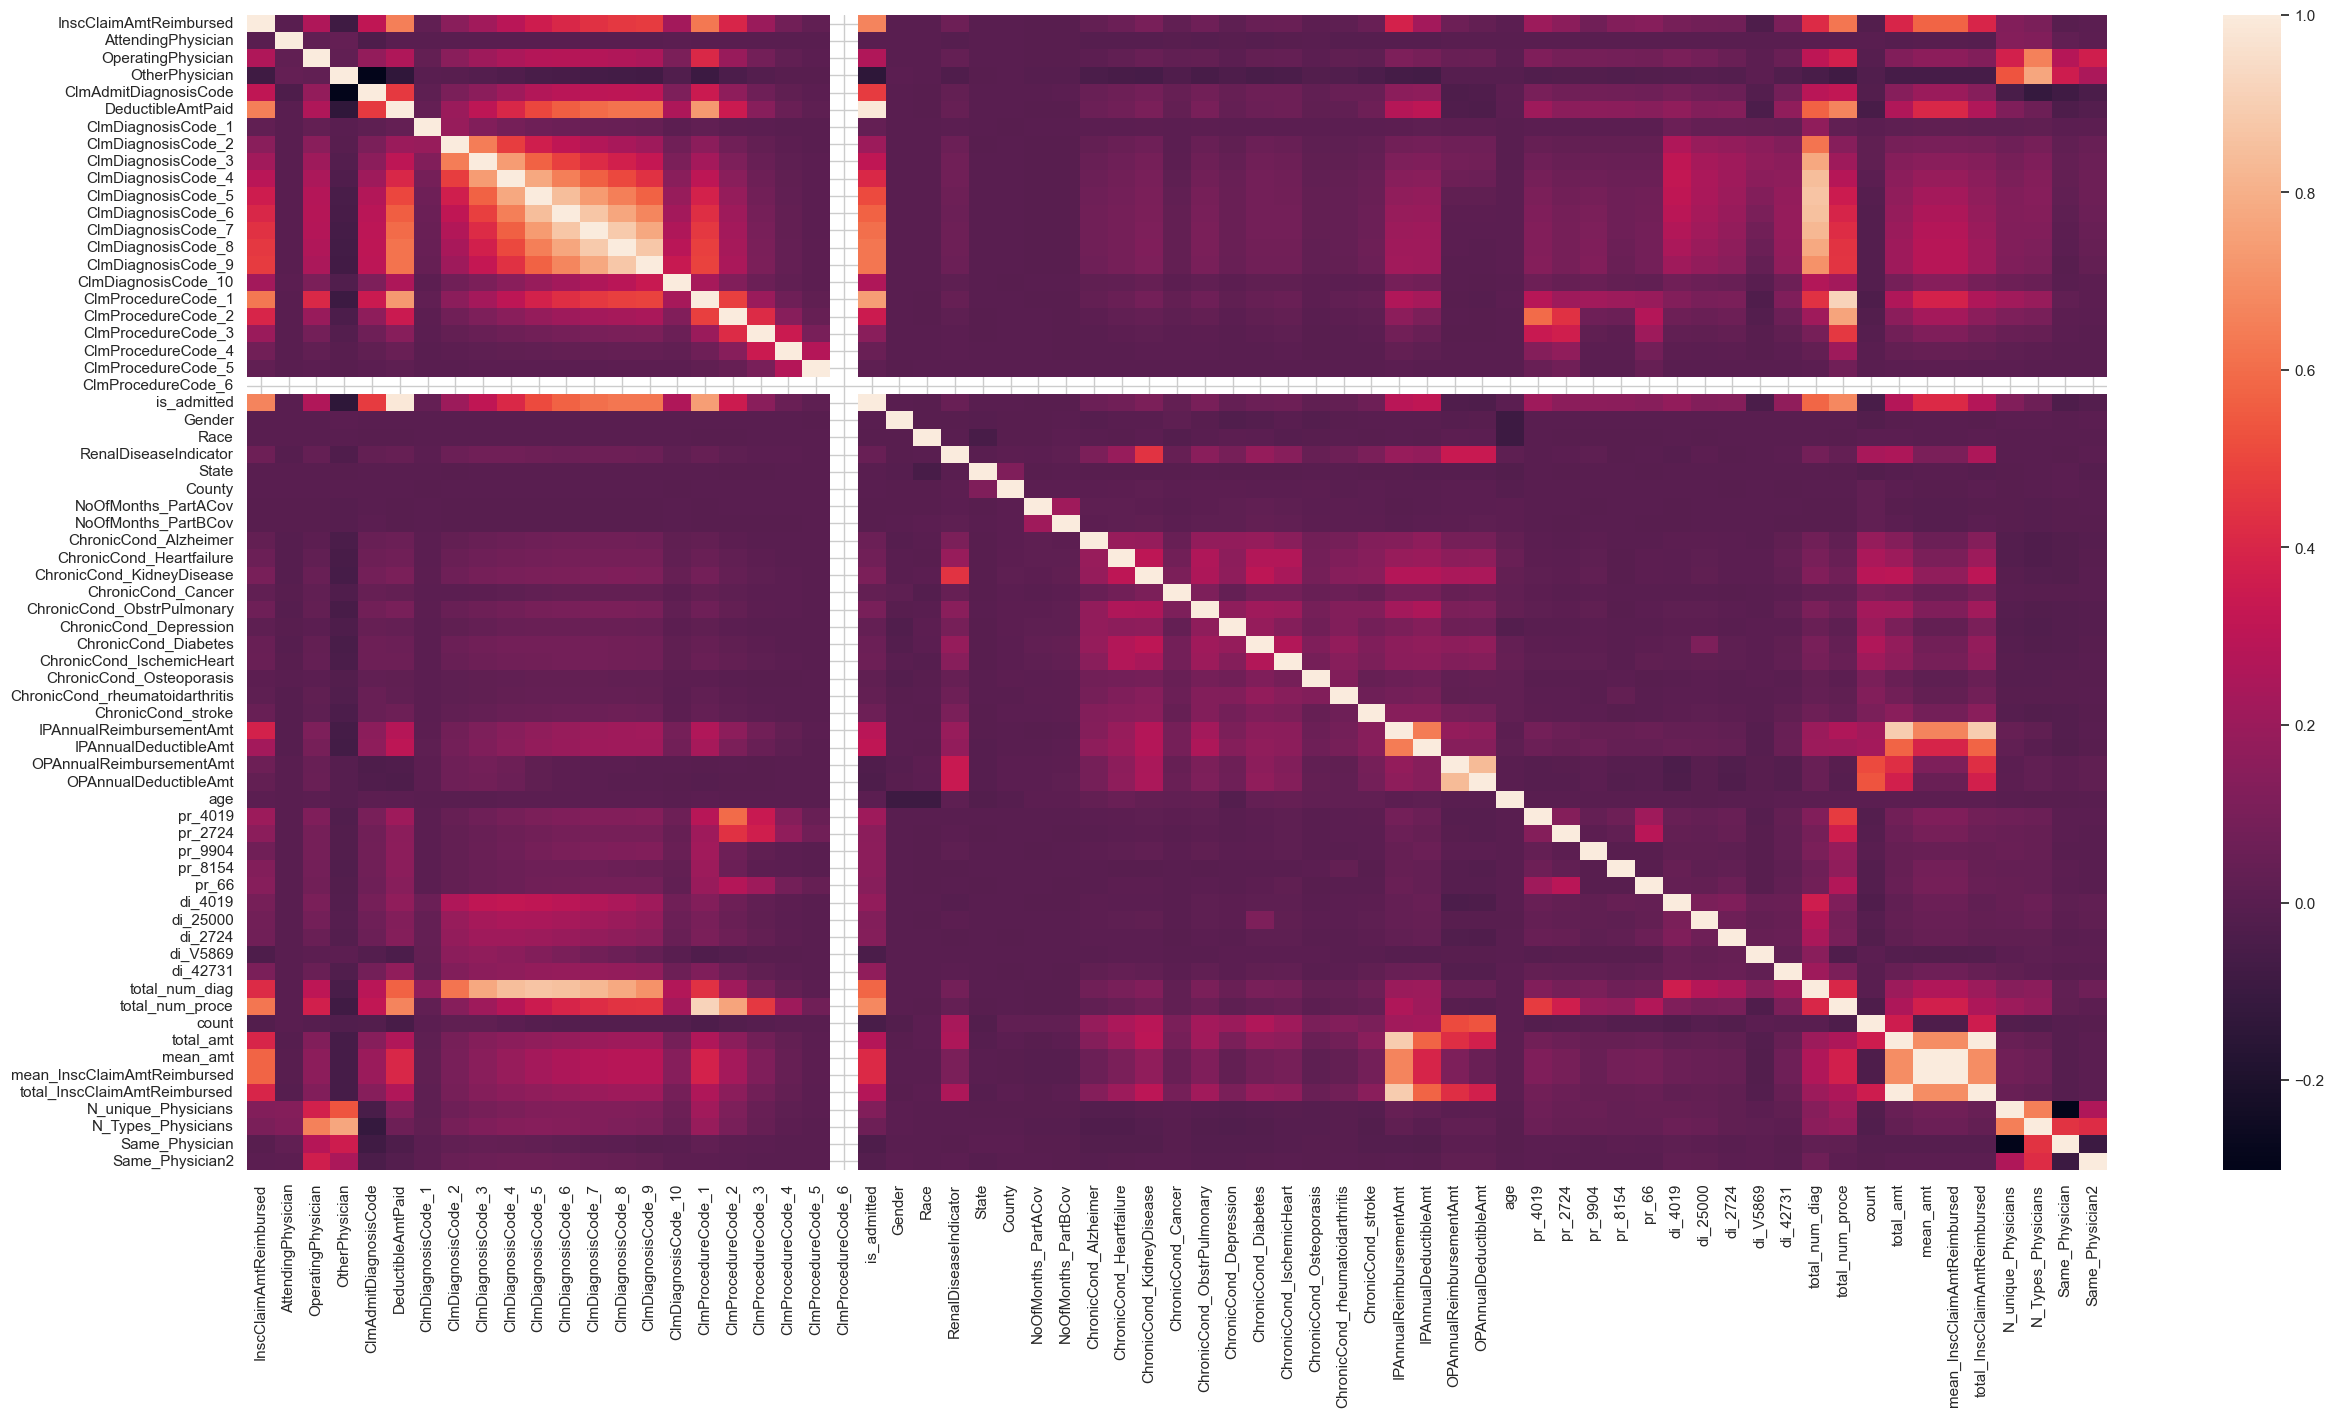

In [684]:
#plot correlation heat map between features
sns.set(context='notebook', style='whitegrid')
plt.figure(figsize=(30, 15))
corr = data_final.corr( numeric_only=True)
sns.heatmap(corr, annot=False)

In [685]:
#replace NaN val with 0
#data_final.DiagnosisGroupCode
data_final['DiagnosisGroupCode']= data_final['DiagnosisGroupCode'].replace({np.nan:0})

In [686]:
#final check to see if a col val is NaN
col_inf_df=pd.DataFrame() 
val = data_final.isnull().sum()
col_inf_df['null_col_count']  = val
col_inf_df['column'] = val.index
col_inf_df.loc[col_inf_df['null_col_count'] !=0]

,null_col_count,column
Physician_Team,467602,Physician_Team


In [687]:
#saving dataframe to csv file to avoid rework
data_final.to_csv("data_final.csv",index= False)

In [688]:
data_final = pd.read_csv("data_final.csv")

In [689]:
# Now we will drop the columns that are not useful for building machine learning models to predict fraudulent providers. 
# We will keep only the relevant features that we have engineered and the target variable in our final dataset.

col_to_remove = ['Provider','BeneID', 'ClaimID', 'ClaimStartDt','ClaimEndDt','AttendingPhysician',\
                 'OperatingPhysician', 'OtherPhysician','ClmAdmitDiagnosisCode','NoOfMonths_PartACov',\
                 'NoOfMonths_PartBCov','DiagnosisGroupCode','PotentialFraud']

data_final.drop(columns=col_to_remove, axis=1, inplace=True)
data_final['target']=data_final['target'].astype(int)

# Conclusion

To start with we performed some EDA tasks which were remaining from the Milestone 1 

We performed the data cleaning and preprocessing.

We performed tasks like below

* Feature Transformation in Calculation of Age, Binary Annotation to medical condition.
* Engineer New feature like Total amount for each Beneficiary and Consolidating Proc and diag codes
* Drop Feature like DOB and DOD, when the feature was not useful for the model
* Performing data extraction like Potential Fraud Provider in the dataset.
* Making Deductible amount as 0 when data is NULL.
* We used the Correlation Heat Map to drop redundant features.

# Model Building and Evaluation
# Milestone 3 **************************************************************************************** 

In Milestone 3, you will begin the process of selecting, building, and evaluating a model. You are required to train and evaluate at least one model in this milestone. Write step-by-step for performing each of these steps. You can use any methods/tools you think are most appropriate, but you should explain/justify why you are selecting the model(s) and evaluation metric(s) you choose. It is important to think about what type of model and metric makes sense for your problem. Again, do what makes the most sense for your project. Write a short overview/conclusion of the insights gained from your model building/evaluation.

It is important to note that these milestones are meant to keep you on track for the final project submission. At any point, you can pivot or modify your project as needed based on what you discover. These milestones are not final versions; they are drafts of the many steps you need to complete along the way.

In [690]:
# Now we have a final dataset with all the relevant features and the target variable indicating potential fraud. 
# We can now proceed to build machine learning models to predict fraudulent providers based on these features.
# Dropping the Physician_Team column as it is not useful for building machine learning models and has object type which can cause issues in modeling. 
# We will keep only the relevant features that we have engineered and the target variable in our final dataset.

data_final = data_final.drop(['Physician_Team'], axis=1, errors='ignore')
y = data_final['target']
X = data_final.drop('target', axis=1)

In [691]:
# Now we will split the data into training and testing sets to build machine learning models to predict fraudulent providers 
# based on the features in our final dataset. We will use a stratified split to ensure that the distribution of the target variable 
# is maintained in both the training and testing sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)


print("Shapes data into train,test,CV splitting..")
print("Training X : ",X_train.shape," | Training Y : ",y_train.shape)
print("Test X : ",X_test.shape," | Test Y : ",y_test.shape)

Shapes data into train,test,CV splitting..
Training X :  (374001, 63)  | Training Y :  (374001,)
Test X :  (184210, 63)  | Test Y :  (184210,)


In [692]:
# Baseline model using Logistic Regression without any feature scaling or normalization to check the performance of the model on the original dataset.
# Before building complex models, you must select a Baseline Model. A baseline provides a "floor" for performance—if a complex model can't beat a simple one, the complexity isn't justified.

# Now we will normalize the numerical columns in our training and testing datasets to ensure that they are on the same scale. 
# This will help in improving the performance of machine learning models.

# By using .reshape(-1, 1), both your training and testing sets are seen as having exactly 1 feature. 
# This is crucial for the scaler to work correctly, as it expects a 2D array where rows are samples and columns are features.

from sklearn.preprocessing import StandardScaler

def num_col_normalizer(X_tr, X_te, col=''):
    """This function returns scaled columns for train and test data using StandardScaler"""
    scaler = StandardScaler()
    
    # Reshape to (-1, 1) -> This means 'many rows, 1 feature'
    # This ensures the 'feature count' is always 1, regardless of row count
    train_col = X_tr[col].values.reshape(-1, 1)
    test_col = X_te[col].values.reshape(-1, 1)
    
    scaler.fit(train_col)
    
    tr = scaler.transform(train_col)
    te = scaler.transform(test_col)
    
    return tr, te

#InscClaimAmtReimbursed
tr,te = num_col_normalizer(X_train, X_test,col='InscClaimAmtReimbursed')
X_train['InscClaimAmtReimbursed'] = tr
X_test ['InscClaimAmtReimbursed'] = te

tr,te = num_col_normalizer(X_train, X_test,col='DeductibleAmtPaid')
X_train['DeductibleAmtPaid'] = tr
X_test ['DeductibleAmtPaid'] = te

tr,te = num_col_normalizer(X_train, X_test,col='IPAnnualReimbursementAmt')
X_train['IPAnnualReimbursementAmt'] = tr
X_test ['IPAnnualReimbursementAmt'] = te

tr,te = num_col_normalizer(X_train, X_test,col='IPAnnualDeductibleAmt')
X_train['IPAnnualDeductibleAmt'] = tr
X_test ['IPAnnualDeductibleAmt'] = te

tr,te = num_col_normalizer(X_train, X_test,col='OPAnnualReimbursementAmt')
X_train['OPAnnualReimbursementAmt'] = tr
X_test ['OPAnnualReimbursementAmt'] = te

tr,te = num_col_normalizer(X_train, X_test,col='OPAnnualDeductibleAmt')
X_train['OPAnnualDeductibleAmt'] = tr
X_test ['OPAnnualDeductibleAmt'] = te

tr,te = num_col_normalizer(X_train, X_test,col='mean_InscClaimAmtReimbursed')
X_train['mean_InscClaimAmtReimbursed'] = tr
X_test ['mean_InscClaimAmtReimbursed'] = te

tr,te = num_col_normalizer(X_train, X_test,col='total_InscClaimAmtReimbursed')
X_train['total_InscClaimAmtReimbursed'] = tr
X_test ['total_InscClaimAmtReimbursed'] = te


tr,te = num_col_normalizer(X_train, X_test,col='age')
X_train['age'] = tr
X_test ['age'] = te
        
tr,te = num_col_normalizer(X_train, X_test,col='Num_admit_days')
X_train['Num_admit_days'] = tr
X_test ['Num_admit_days'] = te

tr,te = num_col_normalizer(X_train, X_test,col='N_unique_Physicians')
X_train['N_unique_Physicians'] = tr
X_test ['N_unique_Physicians'] = te


tr,te = num_col_normalizer(X_train, X_test,col='N_Types_Physicians')
X_train['N_Types_Physicians'] = tr
X_test ['N_Types_Physicians'] = te

In [693]:
# Now we will build a logistic regression model using the training dataset and evaluate its performance on the testing dataset.

def get_threshold_fpr_tpr(y, y_pred_prob):
    fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
    return fpr, tpr, thresholds

# Now we will plot the ROC curve and calculate the AUC score for the logistic regression model to evaluate its performance.
def draw_Roc_Auc_plot(train_fpr, train_tpr,test_fpr, test_tpr):
    plt.plot(train_fpr, train_tpr, label="train AUC = "+str(auc(train_fpr, train_tpr)))
    plt.plot(test_fpr, test_tpr, label="test AUC = "+str(auc(test_fpr, test_tpr)))
    plt.legend()
    plt.xlabel("K: hyperparameter")
    plt.ylabel("AUC")
    plt.title("ERROR PLOTS")
    plt.grid()
    plt.show()

# determining best threshold
def find_best_threshold(threshold, fpr, tpr):
    t = threshold[np.argmax(tpr*(1-fpr))]
    print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

# predicting Yq for given Xq with best threshold:
def predict_with_best_t(proba, threshold):
    predictions = []
    for i in proba:
        if i>=threshold:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

# Now we will plot the confusion matrix for the logistic regression model using the best threshold to evaluate its performance in terms of true positives, 
# true negatives, false positives and false negatives.
def get_confusion_matrix(y, y_pred,axis, best_t):
    cm = pd.DataFrame(confusion_matrix(y, predict_with_best_t(y_pred, best_t)))
    sns.heatmap(cm, annot = True, fmt= 'd',annot_kws={"size": 15}, xticklabels= ['Predicted No', 'Predicted Yes'], yticklabels= ['Actual No','Actual Yes'],ax=axis)

In [696]:
# This function will check the performance of the model by plotting the ROC curve, calculating the AUC score, 
# finding the best threshold and plotting the confusion matrix for both training and testing datasets.

def model_performance_check(model,X_train,X_test,y_train,y_test):
    
    y_train_pred = model.predict_proba(X_train)[:,1]    
    y_test_pred = model.predict_proba(X_test)[:,1]
    
    train_fpr, train_tpr, tr_thresholds = get_threshold_fpr_tpr(y_train, y_train_pred)
    test_fpr, test_tpr, te_thresholds = get_threshold_fpr_tpr(y_test, y_test_pred)
    
    #plot Roc_AUC_curve
    draw_Roc_Auc_plot(train_fpr, train_tpr,test_fpr, test_tpr)
    
    best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
    
    #draw confusion matrix
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5,3)) 

    #training confusion matrix heatmap
    get_confusion_matrix(y_train, y_train_pred,ax[0], best_t)
    ax[0].set_title("confusion matrix for training data")

    #test confusion matrix heatmap
    get_confusion_matrix(y_test, y_test_pred,ax[1], best_t)
    ax[1].set_title("confusion matrix for test data")
    
    actual_output = y_test
    pred_output = predict_with_best_t(y_test_pred, best_t)
    
    model_f1_score = metrics.f1_score(actual_output,pred_output)
    print("Model test F1 score is : ",model_f1_score)
    
    model_AUC_score = metrics.auc(test_fpr, test_tpr)
    print("Model test AUC score is : ",model_AUC_score)
    
    return (model_f1_score, model_AUC_score)


# Model : Using All Features

## Model 1 : Logistic Regression as Base

In [ ]:
import os

# This must be set BEFORE any other imports to affect parallel workers
os.environ['PYTHONWARNINGS'] = 'ignore'

import numpy as np
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Supplemental silence for the main process
np.seterr(all='ignore')
warnings.filterwarnings('ignore')

# Now run your GridSearchCV as usual
grid = {"C": np.logspace(-3, 3, 7), "penalty": ["l1", "l2"]}
logreg = LogisticRegression(solver='liblinear') 

# Ensure verbose=0 so the internal joblib doesn't bypass the filter
logreg_cv = GridSearchCV(logreg, grid, cv=10, n_jobs=-1, verbose=0)
logreg_cv.fit(X_train, y_train)


print("tuned hyperparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

In [ ]:
# Now we will build a logistic regression model using the best hyperparameters obtained from the grid search and evaluate its performance on the testing dataset.
logreg2=LogisticRegression(C=0.01,penalty="l2")
logreg2.fit(X_train,y_train)
print("score",logreg2.score(X_test,y_test))

score 0.6287552250149286


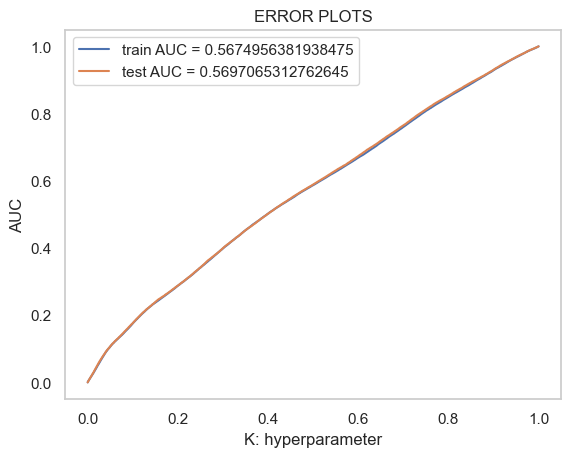

the maximum value of tpr*(1-fpr) 0.30204476269471753 for threshold 0.387
Model test F1 score is :  0.47135830101761966
Model test AUC score is :  0.5697065312762645


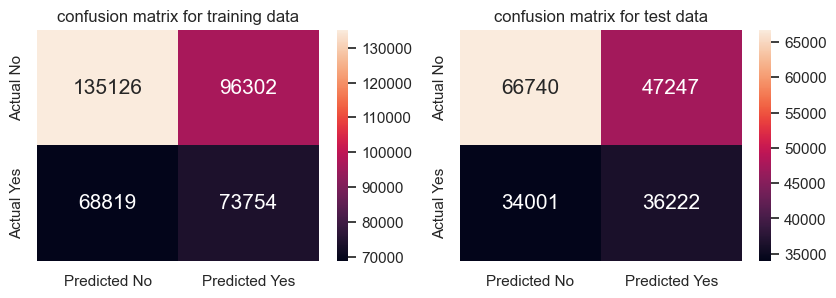

In [ ]:
# Now we will check the performance of the logistic regression model by plotting the ROC curve, calculating the AUC score, 
# finding the best threshold and plotting the confusion matrix for both training and testing datasets.
model_f1_score, model_AUC_score = model_performance_check(logreg2,X_train,X_test,y_train,y_test)

## Model 2: Decision Tree

In [ ]:
# Now we will build a decision tree classifier using the training dataset and evaluate its performance on the testing dataset. 
# We will use grid search to find the best hyperparameters for the decision tree model.

from sklearn.tree import DecisionTreeClassifier

DT_model = DecisionTreeClassifier(class_weight = 'balanced')

parameters = {'max_depth': [1, 5, 10, 50, 100, 500, 1000], 'min_samples_split': [5, 10,20, 45, 75, 100, 135, 270, 500]}

DT_model_CV = GridSearchCV(DT_model, parameters, cv=5, scoring='roc_auc', n_jobs=-1, return_train_score=True, verbose=0)
DT_model_CV = DT_model_CV.fit(X_train,y_train)

print("tuned hyperparameters :(best parameters) ",DT_model_CV.best_params_)
print("roc_auc :",DT_model_CV.best_score_)

tuned hyperparameters :(best parameters)  {'max_depth': 50, 'min_samples_split': 270}
roc_auc : 0.8210535949416571


In [ ]:
# model with best hyperparameters:
DT_model2 = DecisionTreeClassifier(class_weight = 'balanced', max_depth = 50, min_samples_split = 270)
DT_model2=DT_model2.fit(X_train,y_train)

print("score",DT_model2.score(X_test,y_test))

score 0.7533087237392107


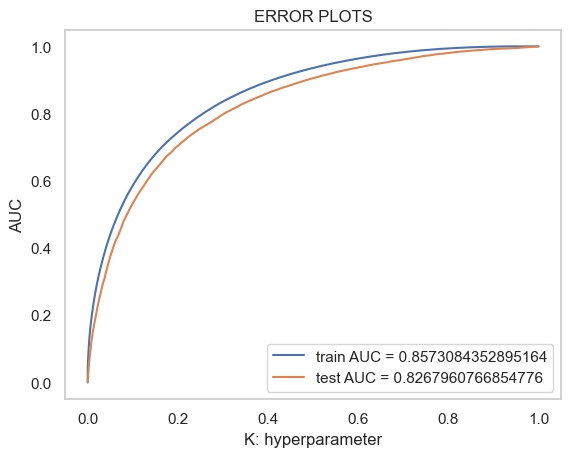

the maximum value of tpr*(1-fpr) 0.5974797424456386 for threshold 0.501
Model test F1 score is :  0.6988675144294167
Model test AUC score is :  0.8267960766854776


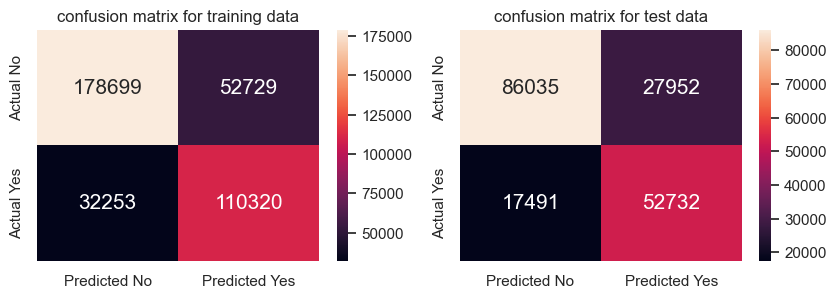

In [ ]:
# Now we will check the performance of the decision tree model by plotting the ROC curve, calculating the AUC score, 
# finding the best threshold and plotting the confusion matrix for both training and testing datasets.

model_f1_score, model_AUC_score = model_performance_check(DT_model2,X_train,X_test,y_train,y_test)

NameError: name 'importances' is not defined

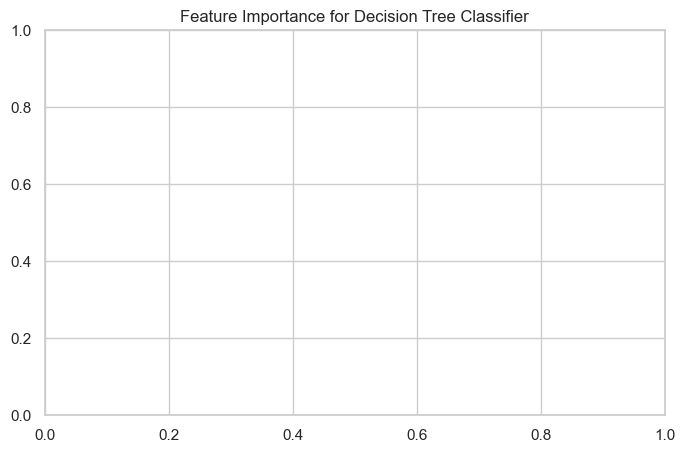

In [ ]:
# Now we will plot the feature importance for the decision tree model to analyze which features are most important 
# in predicting fraudulent providers in the dataset.

features = data_final.columns
importance = DT_model2.feature_importances_
indices = (np.argsort(importance))[-15:]
plt.figure(figsize=(8,5))
plt.title('Feature Importance for Decision Tree Classifier')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Model 3: Random Forest

### Random Forest is the industry standard for tabular healthcare data because they handle non-linear relationships and missing values exceptionally well. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(class_weight = 'balanced', random_state=42)

param_grid = { 
    'n_estimators': [300, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}


RF_CV = GridSearchCV(estimator=RF, param_grid=param_grid, cv= 5,scoring='roc_auc', n_jobs=-1, return_train_score=True, verbose=0)
RF_CV.fit(X_train, y_train)

print("tuned hyperparameters :(best parameters) ",RF_CV.best_params_)
print("roc_auc :",RF_CV.best_score_)

In [ ]:
RF2 = RandomForestClassifier(n_estimators = 300,max_features='sqrt',max_depth=8,criterion='gini',
                             class_weight = 'balanced',n_jobs=-1,verbose=0, random_state=42)

RF2=RF2.fit(X_train,y_train)

print("score",RF2.score(X_test,y_test))

In [ ]:
model_f1_score, model_AUC_score = model_performance_check(RF2,X_train,X_test,y_train,y_test)

In [ ]:
features = data_final.columns
importances = RF2.feature_importances_
indices = (np.argsort(importances))[-30:]
plt.figure(figsize=(8,7))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
!pip install xgboost

# XG Boost : XGBoost is favored for its speed and its ability to assign higher weights to the minority class (the "fraud" cases) during training.

In [ ]:
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV

XGB = xgb.XGBClassifier()

parameters = {"eta" : [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3] , "n_estimators" : [5,10,50, 75, 100]}

XGB_CV = RandomizedSearchCV(XGB, parameters , cv=5, scoring='roc_auc', n_jobs=-1,return_train_score=True, verbose=0)
XGB_CV.fit(X_train,y_train)

print("tuned hyperparameters :(best parameters) ",XGB_CV.best_params_)
print("roc_auc :",XGB_CV.best_score_)

In [ ]:
XGB2 = xgb.XGBClassifier(eta=0.3,n_estimators=100,n_jobs=-1)

XGB2=XGB2.fit(X_train,y_train)

print("score",XGB2.score(X_test,y_test))

In [ ]:
model_f1_score, model_AUC_score = model_performance_check(XGB2,X_train,X_test,y_train,y_test)

In [ ]:
features = data_final.columns
importances = XGB2.feature_importances_
indices = (np.argsort(importances))[-30:]
plt.figure(figsize=(8,7))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
def model_comp(label=[],metric1=[],metric2=[],set_ylabel='',set_title='',metric1_label='',metric2_label=''):
    
    x = np.arange(len(model))  # the label locations
    width = 0.35  # the width of the bars
    
    fig, ax = plt.subplots(figsize=(12,5))
    rects1 = ax.bar(x - width/2, metric1, width, label=metric1_label,color = 'teal')
    rects2 = ax.bar(x + width/2, metric2, width, label=metric2_label)
    
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(set_ylabel)
    ax.set_title(set_title)
    ax.set_xticks(x)
    ax.set_xticklabels(model)
    ax.legend()
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)
    
    fig.tight_layout()

    plt.show()

In [ ]:
model = ['LR','DT','RF','XG_Boost']
f1_score = [0.4713,0.6988,0.5447,0.6945]
AUC_score = [0.5697,0.8268,0.6511,0.8201]

model_comp(model,f1_score,AUC_score,'Scores','Model performance Summary','f1_score','AUC_score')

In [ ]:
model_performance_df = pd.DataFrame()
model = ['LR','DT','RF','XG_Boost']
f1_score = [0.4713,0.6988,0.5447,0.6945]
AUC_score = [0.5697,0.8268,0.6511,0.8201]

model_performance_df['Model']=model
model_performance_df['f1_score']=f1_score
model_performance_df['AUC_score']=AUC_score
model_performance_df

# Conclusion 

Surprisingly, the Decision Tree (DT) is currently the top performer, slightly edging out XGBoost in both F1 and AUC.

An AUC of 0.8268 suggests the model has a strong ability to distinguish between a fraudulent provider and a legitimate one. In healthcare fraud, the "rules" are often binary (e.g., Is the patient deceased? Yes/No). Decision Trees excel at these hard-logic splits.

The Random Forest (RF) (F1: 0.5447) is significantly underperforming compared to the single Decision Tree. This usually happens if the max_depth is too shallow or if the class_weight='balanced' isn't aggressive enough. The "forest" might be averaging out the rare fraud signals that the single tree is catching.

With an F1 of 0.4713, the linear model is struggling. Fraudulent behavior is rarely linear. A single high-cost claim isn't fraud; it's the combination of frequency, location, and patient age. LR cannot "see" these combinations without complex manual feature engineering.


Because we are working on Healthcare Fraud which is "needle in a haystack" , F1-Score and AUC score more over Accuracy. F1 is the best metric because it balances the cost of missing fraud (Recall) against the cost of accusing an innocent provider (Precision).

AUC-ROC tells the probability that a randomly chosen fraud case will be ranked higher by the model than a randomly chosen legitimate case. 0.82 is a "Good" score for this domain.

Winning Model - While DT has the highest score, XGBoost (0.6945 F1) is often preferred in production because it is less prone to "overfitting" (memorizing the training data) than a single deep Decision Tree.

Since there is a significant gap between AUC (0.82) and F1 (0.69) which also means the model is good at ranking providers by risk, but it struggles to set the exact "cutoff" point to decide who is definitely fraudulent.

We can run the same test using selected features in next Milestone as conclusion.
Will change the verbose =0 in order to reduce the messages. Couldn't perform it as RF is taking lot of time to complete. Will ensure to reduce the size in final submission.